## import

In [3]:
import numpy as np 
import pandas as pd
import random 
import os
from typing import Tuple, List
import time

# https://discuss.pytorch.org/t/how-to-enable-torch-use-cuda-dsa/202824/5
os.environ['CUDA_LAUNCH_BLOCKING'] = "1"
os.environ['TORCH_USE_CUDA_DSA'] = "1"
# https://discuss.pytorch.org/t/keep-getting-cuda-oom-error-with-pytorch-failing-to-allocate-all-free-memory/133896/10
# https://dev.to/shittu_olumide_/how-can-i-set-maxsplitsizemb-to-avoid-fragmentation-in-pytorch-37h9
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "max_split_size_mb:64 "

from tqdm import tqdm
import torch
import copy
import torch.nn.functional as F
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import make_column_selector as selector
from sklearn.compose import ColumnTransformer
import torch_geometric
# from torch_geometric import seed_everything
from torch_geometric.data import Data, HeteroData
from torch_geometric.loader import NeighborLoader, ImbalancedSampler
import torch_geometric.transforms as T
import torch_geometric.utils as U
from torch_geometric.utils import coalesce
from torch_geometric.nn import summary, HeteroConv, GATv2Conv, SAGEConv, Linear
import pyg_lib
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve, average_precision_score, f1_score, auc, precision_recall_fscore_support, matthews_corrcoef 
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

import tempfile
# edit the line below to specify specify tmp_directory
# tempfile.tempdir = ''

torch.multiprocessing.set_sharing_strategy('file_system')
# https://stackoverflow.com/questions/71642653/how-to-resolve-the-error-runtimeerror-received-0-items-of-ancdata
import resource
rlimit = resource.getrlimit(resource.RLIMIT_NOFILE)
resource.setrlimit(resource.RLIMIT_NOFILE, (4096, rlimit[1]))

print(f"numpy.__version__ = {np.__version__}")
print(f"pandas.__version__ = {pd.__version__}")
print(f"torch.__version__ = {torch.__version__}")
print(f"torch_geometric.__version__ = {torch_geometric.__version__}")
print(f"pyg_lib.__version__ = {pyg_lib.__version__}")

hyperparameters = {
    'node_mode' : 'degree', #'id' or 'degree' for abcm nodes_types
    'edge_features' : False, # True = those are the true edge_weights from my network
    'Heads' : 1, #2
    # 'conv_number' : 2, 
    'conv_type': 'SAGE',
    'sage_aggr': 'sum', # 'sum', 'var'
    'sage_norm': True, # False
    'sage_project': False,
    'heteroconv_aggr' : 'sum', # 'cat', 'max'
    'heteroconv_aggr_1' : 'sum', # 'sum', 'cat', 'max'
    'heteroconv_aggr_2' : 'sum', # 'sum', 'cat', 'max'
    'heteroconv_aggr_3' : 'sum', # 'cat', 'max'
    # 'activation': 'relu', # 'tanh'
    'hc_2_q' : 1, # hc_2 = int(i/hc_2_q)
    'hc_3_q': 1, # hc_3_q = int(i/hc_3_q)
    'size_of_batch': 128,
    'neighbors': 30,
    'disjoint_loader' : True, 
    'zero_out_batch_features': True,
    'epochs_to_train' : 500, # maximum number of epochs to train 
    'min_epochs_to_train': 3,
    'patience': 10,
    'min_delta': 0.005,
    'auto_loop': False,
    # 'nodes_pairs_features': 'zeros', # for p2p or n2p only
    # 'remove_forbidden_value': True, # for p2p or n2p only
    # 'ana_edges': 'common', # 'all
    'type_to_return': 'torch', # 'numpy'
    'final_type': 'torch', # 'numpy'
    'shuffle_train': True,
    'string_threshold': 700, # confidence = {'low': 150, 'medium': 400, 'high': 700, 'highest': 900} from STRING doc
    'setting': 'nodes_to_nodes',
    'target_to_use': 'essential',
    'features_to_use': 'basic' # features in ['basic', 'strict', 'large']
}

dict_j = {1:'01', 2:'02', 3:'03', 4:'04', 5:'05', 6:'06', 7:'07', 8:'08', 9:'09', 10:'10'}

sage_aggr = hyperparameters['sage_aggr'] # 'sum'
sage_norm = hyperparameters['sage_norm'] # 'sum'
heteroconv_aggr = hyperparameters['heteroconv_aggr'] #'sum', 'cat'
heteroconv_aggr_1 = hyperparameters['heteroconv_aggr_1'] #'sum', 'cat'
heteroconv_aggr_2 = hyperparameters['heteroconv_aggr_2'] #'sum', 'cat'
heteroconv_aggr_3 = hyperparameters['heteroconv_aggr_3'] #'sum', 'cat'
node_mode = hyperparameters['node_mode'] # 'id' or 'degree'
sage_norm = hyperparameters['sage_norm']
Heads = hyperparameters['Heads']
# ana_edges = hyperparameters['ana_edges']
# conv_number = hyperparameters['conv_number']
string_threshold = hyperparameters['string_threshold']

setting = hyperparameters['setting']
conv_type = hyperparameters['conv_type']
heads = hyperparameters['Heads']
neighbors = hyperparameters['neighbors']
patience = hyperparameters['patience']
min_delta = hyperparameters['min_delta']
zero_out_batch_features = hyperparameters['zero_out_batch_features']
epochs_to_train = hyperparameters['epochs_to_train']
size_of_batch = hyperparameters['size_of_batch']
target_of_script = hyperparameters['target_to_use']
features = 'basic' # 4 features, data['GENE'].x.shape will be (19330,4)

t0 = time.time()

old_path = os.getcwd()
new_path = old_path + '/../../'
os.chdir(new_path)
current_path = os.getcwd()
data_raw_path = current_path + '/data/raw/'
data_processed_path = current_path + '/data/processed/'

numpy.__version__ = 1.26.3
pandas.__version__ = 2.2.1
torch.__version__ = 2.1.2+cu118
torch_geometric.__version__ = 2.5.2
pyg_lib.__version__ = 0.3.1+pt21cu118


In [4]:
my_dict = {}

string_threshold = -1

# open the Human_Knowledge_Graph
net = pd.read_csv(data_processed_path + f'human_knowledge_graph.tsv', sep = '\t', header = 0, dtype = {1: str, 3: str, 4: str})
net = net.drop(net[(net['EdgeType'].isin(['PPI'])) & (net['EdgeScore'] < string_threshold)].index, axis = 0)
net = net.reset_index(drop = True)
# I will not be using these edges,maybe in a future version ? 
edges_to_remove = [
    'CoExp', 'Neighbour', 
    'not_expressed_in', 'DIDA',
    'synthetic_lethal', 'synthetic_non_lethal', 
    'regulatory_proximal', 'regulatory_distal'
    ]
net = net.drop(net[net['EdgeType'].isin(edges_to_remove)].index, axis=0)
net = net.reset_index(drop=True)

for string_threshold in [-1, 150, 400, 700, 900]:
    net = net.drop(net[(net['EdgeType'].isin(['PPI'])) & (net['EdgeScore'] < string_threshold)].index, axis = 0)
    net = net.reset_index(drop = True)
    all_genes = list(set().union(net[net['node1_type'] == 'GENE']['node1_ID'].unique(), net[net['node2_type'] == 'GENE']['node2_ID'].unique()))  
    all_genes.sort()
    my_dict[string_threshold] = all_genes
    print(f"- For string_threshold: {string_threshold}, the number of GENES is: {len(all_genes)}")

- For string_threshold: -1, the number of GENES is: 19424
- For string_threshold: 150, the number of GENES is: 19424
- For string_threshold: 400, the number of GENES is: 19363
- For string_threshold: 700, the number of GENES is: 19330
- For string_threshold: 900, the number of GENES is: 19304


- For string_threshold: -1, the number of GENES is: 19424
- For string_threshold: 150, the number of GENES is: 19424
- For string_threshold: 400, the number of GENES is: 19363
- For string_threshold: 700, the number of GENES is: 19330
- For string_threshold: 900, the number of GENES is: 19304

In [5]:
# open the Human_Knowledge_Graph
string_threshold = 700
net = pd.read_csv(data_processed_path + f'human_knowledge_graph.tsv', sep = '\t', header = 0, dtype = {1: str, 3: str, 4: str})
net = net.drop(net[(net['EdgeType'].isin(['PPI'])) & (net['EdgeScore'] < string_threshold)].index, axis = 0)
net = net.reset_index(drop = True)
# I will not be using these edges,maybe in a future version ? 
edges_to_remove = [
    'CoExp', 'Neighbour', 
    'not_expressed_in', 'DIDA',
    'synthetic_lethal', 'synthetic_non_lethal', 
    'regulatory_proximal', 'regulatory_distal'
    ]
net = net.drop(net[net['EdgeType'].isin(edges_to_remove)].index, axis=0)
net = net.reset_index(drop=True)

In [6]:
all_genes = list(set().union(net[net['node1_type'] == 'GENE']['node1_ID'].unique(), net[net['node2_type'] == 'GENE']['node2_ID'].unique()))
# I could hardcode edges_names, edge_summary eveneutally
edges_names = net['EdgeType'].value_counts().to_dict()
edges_summary = []
for edge_name in edges_names.keys():
    tmp_list = [edge_name, 
                net[net['EdgeType'] == edge_name]['node1_type'].unique()[0], 
                net[net['EdgeType'] == edge_name]['node2_type'].unique()[0], 
                net[net['EdgeType'] == edge_name]['EdgeDirection'].unique()[0], 
                edges_names[edge_name]]
    # create a special case when there are edge_attributes
    # not currently using edges_attributes, but maybe in a future version 
    if sum(net[net['EdgeType'] == edge_name]['EdgeScore'].isna()) == 0:
        tmp_list.append(1)
    else:
        tmp_list.append(0)
    edges_summary.append(tmp_list) 

edges_types = list(set(net['EdgeType'].unique()))
nodes_types = list(set().union(net['node1_type'].unique(),net['node2_type'].unique()))
nodes_types.sort()
nodes_numbers = {}
for node_type in nodes_types:
    nodes_numbers[node_type] = len(set().union(net[net['node1_type'] == node_type]['node1_ID'].unique(), net[net['node2_type'] == node_type]['node2_ID'].unique()))

print(f"nodes_types: {nodes_types}")
print(f"nodes_numbers: {nodes_numbers}")

list_of_edges = net['EdgeType'].unique().tolist()

nodes_types: ['ANATOMY', 'BP', 'CC', 'GENE', 'MF']
nodes_numbers: {'ANATOMY': 14337, 'BP': 27993, 'CC': 4039, 'GENE': 19330, 'MF': 11271}


In [7]:
def Get_df_for_nodetype_id(df: pd.DataFrame, node_type : str) -> pd.DataFrame:
    node_type_list = list(set().union(df[df['node1_type'] == node_type]['node1_ID'].unique(), df[df['node2_type'] == node_type]['node2_ID'].unique()))
    node_type_list.sort()
    node_type_array = np.asarray(node_type_list)
    new_df = pd.DataFrame(data = {
        f"{node_type}_id": node_type_array,
        "mapped_id": pd.RangeIndex(len(node_type_array))
    })
    return(new_df)

nodes2id = {}
for type_of_node in nodes_types:
    nodes2id[type_of_node] = Get_df_for_nodetype_id(net, type_of_node)

## correlation matrix features

In [8]:
numerical_columns_selector = selector(dtype_exclude = object)
categorical_columns_selector = selector(dtype_include = object)
numerical_preprocessor = StandardScaler()
categorical_preprocessor = OneHotEncoder(handle_unknown="ignore")

In [9]:
# create columns selectors
numerical_columns_selector = selector(dtype_exclude = object)
categorical_columns_selector = selector(dtype_include = object)
numerical_preprocessor = StandardScaler()
categorical_preprocessor = OneHotEncoder(handle_unknown="ignore")

def get_strict_target_tensors(target_to_use: str = 'essential', features_to_use: str = 'strict', remove_sex_chrom:bool = False):
    nodes2id['GENE'] = nodes2id['GENE'][['GENE_id', 'mapped_id']]
    # open the file with the features values 
    feat = pd.read_csv(data_processed_path + 'human_genes_features_20230414.tsv', sep = '\t', header = 0)
    feat = pd.merge(nodes2id['GENE'], feat, left_on = 'GENE_id', right_on = 'ENSG_ID', how = 'left')
    # open the file with the essential vs non_essential, and remove some of them: pseudogene etc.  
    # TODO update the essential_file
    vitro = pd.read_csv(data_raw_path + 'essentials_invitro_20240214.tsv', sep = '\t', names = ['gene_id'])
    list_to_remove = [
        'ENSG00000158483', 'ENSG00000172014', 'ENSG00000180953', 'ENSG00000183148', 'ENSG00000186825',
        'ENSG00000197927', 'ENSG00000198019', 'ENSG00000204677', 'ENSG00000213029', 'ENSG00000232962', 
        'ENSG00000263091', 'ENSG00000276816', 'ENSG00000282827', 'ENSG00000283472', 'SF3B14']
    # conversion_df = pd.read_csv('/data-cbl/rnicolle/GRL4DD/data/processed/essentials_conversion_dict_20240216.tsv', header = 0, sep = '\t')
    conversion_df = pd.read_csv(data_processed_path + 'essentials_conversion_dict_20240216.tsv', header = 0, sep = '\t')
    my_keys = conversion_df['old_ID'].tolist()
    my_values = conversion_df['new_ID'].tolist()
    conversion_dict = {}
    conversion_dict = {my_keys[i]: my_values[i] for i in range(conversion_df.shape[0])}
    vitro = vitro.drop(vitro[vitro['gene_id'].isin(list_to_remove)].index, axis = 0)
    vitro = vitro.reset_index(drop = True)         
    vitro.replace(to_replace=conversion_dict, inplace=True)   
    # get the essential/non-essential type for each GENE
    feat.loc[:,['type']] = 'non_essential'
    feat.loc[feat[feat['GENE_id'].isin(vitro['gene_id'].tolist())].index, 'type'] = 'essential'
    # choose the target: 'pLI' (0: haplo-sufficient, 1: haplo-sensitive, ), 'essential' (0: non_essential, 1: essential)
    if target_to_use in ['pLI', 'OLIDA', 'proven_SL']:
        feat.loc[feat[feat['pLI'] >= 0.9].index, 'y'] = 1
        feat.loc[feat[feat['pLI'] < 0.9].index, 'y'] = 0
        feat.loc[feat[feat['pLI'].isna()].index, 'y'] = 0
        feat.loc[feat[feat['pLI'] == -1].index, 'y'] = 0
    elif target_to_use == 'essential':
        feat.loc[:, 'y'] = 0
        feat.loc[feat[feat['type'] == 'essential'].index, 'y'] = 1
    elif target_to_use == 'essential_K562':
        essential = pd.read_csv(data_raw_path + 'essentials_K562.tsv', header = 0, sep = '\t')
        feat['type'] = 'non_essential'
        feat.loc[feat[feat['GENE_id'].isin(essential['ENSG_ID'].tolist())].index, 'type'] = 'essential'
        feat.loc[:, 'y'] = 0
        feat.loc[feat[feat['type'] == 'essential'].index, 'y'] = 1
    elif target_to_use == 'essential_A375':
        essential = pd.read_csv(data_raw_path + 'essentials_A375.tsv', header = 0, sep = '\t')
        feat['type'] = 'non_essential'
        feat.loc[feat[feat['GENE_id'].isin(essential['ENSG_ID'].tolist())].index, 'type'] = 'essential'
        feat.loc[:, 'y'] = 0
        feat.loc[feat[feat['type'] == 'essential'].index, 'y'] = 1
    elif target_to_use == 'essential_A549':
        essential = pd.read_csv(data_raw_path + 'essentials_A549.tsv', header = 0, sep = '\t')
        feat['type'] = 'non_essential'
        feat.loc[feat[feat['GENE_id'].isin(essential['ENSG_ID'].tolist())].index, 'type'] = 'essential'
        feat.loc[:, 'y'] = 0
        feat.loc[feat[feat['type'] == 'essential'].index, 'y'] = 1
    elif target_to_use == 'OMIM':
        omim = pd.read_csv(data_raw_path + 'humans_n2n_OMIM_20250826.tsv', header = 0, sep = '\t')
        feat = feat.merge(omim[['GENE_id', 'target']], how='left', left_on='GENE_id', right_on='GENE_id')
        feat = feat.rename(columns = {'target': 'y'})
    else:
        raise Exception(f"Please select either 'pLI' or 'essential' or 'essential_K562' or 'essential_A375' or 'essential_A549' for the target to use.")
    # remove sex_chromosom ? TODO
    if (remove_sex_chrom == True) and (set(['chrX','chrY']).issubset(set(feat['chrom'].unique().tolist())) == True):
        feat = feat.drop(feat[feat['chrom'].isin(['chrX', 'chrY'])].index, axis = 0)
        feat = feat.drop('chrom', axis = 1)
    # some GENES are missing values: get the median value of the GENES of the same class, i.e. haplo-sensitive/sufficient or essential/non_essential
    feat = feat.reset_index(drop = True)
    dict_0 = feat[feat['y'] == 0].median(axis = 0, skipna = True, numeric_only = True).to_dict()
    dict_1 = feat[feat['y'] == 1].median(axis = 0, skipna = True, numeric_only = True).to_dict()
    # some GENES with OMIM target have no features at all, they have target -1
    # for i in ['zscore_mis','zscore_syn','f_parameter']:
    for i in dict_0.keys():
        feat.loc[feat[(feat['y'] == 0) & (feat[i].isna())].index, i] = dict_0[i] 
        feat.loc[feat[(feat['y'] == 1) & (feat[i].isna())].index, i] = dict_1[i] 
    if target_to_use == 'OMIM':
        for i in dict_0.keys():
            feat.loc[feat[(feat['y'] == -1) & (feat[i].isna())].index, i] = dict_0[i] 

    if features_to_use in ['strict', 'basic']:
        feat = feat.drop([
        'GENE_id', 'mapped_id', 'ENSG_ID', 'GeneName', 'chrom', 'loeuf',
        'Haploinsufficiency_Score', 'Haploinsufficiency_Description',
        'Triplosensitivity_Score', 'Triplosensitivity_Description', 'omim_class', 'known_developmental_disorder_genes',
        'DDD_HI_percentage', 'RVIS', 'DOMINO', 'pHI', 'SCoNeS', 'shet_det', 'shet_drift', #'GDI', 
        'ncRVIS', 'ncGERP', 'type'], axis = 1)
    elif features_to_use == 'large':
        feat = feat.drop([
        'GENE_id', 'mapped_id', 'ENSG_ID', 'GeneName', 'chrom', #'loeuf',
        'Haploinsufficiency_Score', 'Haploinsufficiency_Description',
        'Triplosensitivity_Score', 'Triplosensitivity_Description', 'omim_class', 'known_developmental_disorder_genes',
        'DDD_HI_percentage', 
        # 'RVIS', 
        'DOMINO', 'pHI', 
        # 'SCoNeS', 'shet_det', 'shet_drift', #'GDI', 
        'ncRVIS', 'ncGERP', 'type'], axis = 1)
    
    if target_to_use in ['essential', 'essential_K562', 'essential_A375', 'essential_A549'] or features_to_use == 'basic':
        feat = feat.drop('FUSIL', axis = 1) # FUSIL is highly correlated to essentiality
    else: # target_to_use == 'pLI' = keep FUSIL category
        categorical_columns = ['FUSIL']
        feat = pd.get_dummies(feat, columns = categorical_columns, dtype = float)
    feat = feat.drop('pLI', axis = 1)
    numerical_columns = numerical_columns_selector(feat)
    numerical_columns.remove('y')
    feat[numerical_columns] = StandardScaler().fit_transform(feat[numerical_columns])
    gene_feat = feat.copy()
    ### get tensors
    target_tensor = torch.from_numpy(gene_feat.y.values)
    gene_feat = feat.drop('y', axis = 1)
    gene_feat_tensor = torch.from_numpy(gene_feat.values)
    
    return gene_feat_tensor, target_tensor, feat 

### target = 'essential'

In [10]:
remove_sex_chrom = False
target_to_use = 'essential'

nodes2id['GENE'] = nodes2id['GENE'][['GENE_id', 'mapped_id']]
# open the file with the features values 
feat = pd.read_csv(data_processed_path + 'human_genes_features_20230414.tsv', sep = '\t', header = 0)
feat = pd.merge(nodes2id['GENE'], feat, left_on = 'GENE_id', right_on = 'ENSG_ID', how = 'left')
# open the file with the essential vs non_essential, and remove some of them: pseudogene etc.  
# TODO update the essential_file
vitro = pd.read_csv(data_raw_path + 'essentials_invitro_20240214.tsv', sep = '\t', names = ['gene_id'])
list_to_remove = [
    'ENSG00000158483', 'ENSG00000172014', 'ENSG00000180953', 'ENSG00000183148', 'ENSG00000186825',
    'ENSG00000197927', 'ENSG00000198019', 'ENSG00000204677', 'ENSG00000213029', 'ENSG00000232962', 
    'ENSG00000263091', 'ENSG00000276816', 'ENSG00000282827', 'ENSG00000283472', 'SF3B14']
# conversion_df = pd.read_csv('/data-cbl/rnicolle/GRL4DD/data/processed/essentials_conversion_dict_20240216.tsv', header = 0, sep = '\t')
conversion_df = pd.read_csv(data_processed_path + 'essentials_conversion_dict_20240216.tsv', header = 0, sep = '\t')
my_keys = conversion_df['old_ID'].tolist()
my_values = conversion_df['new_ID'].tolist()
conversion_dict = {}
conversion_dict = {my_keys[i]: my_values[i] for i in range(conversion_df.shape[0])}
vitro = vitro.drop(vitro[vitro['gene_id'].isin(list_to_remove)].index, axis = 0)
vitro = vitro.reset_index(drop = True)         
vitro.replace(to_replace=conversion_dict, inplace=True)   
# get the essential/non-essential type for each GENE
feat.loc[:,['type']] = 'non_essential'
feat.loc[feat[feat['GENE_id'].isin(vitro['gene_id'].tolist())].index, 'type'] = 'essential'
# choose the target: 'pLI' (0: haplo-sufficient, 1: haplo-sensitive, ), 'essential' (0: non_essential, 1: essential)
if target_to_use in ['pLI', 'OLIDA', 'proven_SL']:
    feat.loc[feat[feat['pLI'] >= 0.9].index, 'y'] = 1
    feat.loc[feat[feat['pLI'] < 0.9].index, 'y'] = 0
    feat.loc[feat[feat['pLI'].isna()].index, 'y'] = 0
    feat.loc[feat[feat['pLI'] == -1].index, 'y'] = 0
elif target_to_use == 'essential':
    feat.loc[:, 'y'] = 0
    feat.loc[feat[feat['type'] == 'essential'].index, 'y'] = 1
elif target_to_use == 'essential_K562':
    essential = pd.read_csv(data_raw_path + 'essentials_K562.tsv', header = 0, sep = '\t')
    feat['type'] = 'non_essential'
    feat.loc[feat[feat['GENE_id'].isin(essential['ENSG_ID'].tolist())].index, 'type'] = 'essential'
    feat.loc[:, 'y'] = 0
    feat.loc[feat[feat['type'] == 'essential'].index, 'y'] = 1
elif target_to_use == 'essential_A375':
    essential = pd.read_csv(data_raw_path + 'essentials_A375.tsv', header = 0, sep = '\t')
    feat['type'] = 'non_essential'
    feat.loc[feat[feat['GENE_id'].isin(essential['ENSG_ID'].tolist())].index, 'type'] = 'essential'
    feat.loc[:, 'y'] = 0
    feat.loc[feat[feat['type'] == 'essential'].index, 'y'] = 1
elif target_to_use == 'essential_A549':
    essential = pd.read_csv(data_raw_path + 'essentials_A549.tsv', header = 0, sep = '\t')
    feat['type'] = 'non_essential'
    feat.loc[feat[feat['GENE_id'].isin(essential['ENSG_ID'].tolist())].index, 'type'] = 'essential'
    feat.loc[:, 'y'] = 0
    feat.loc[feat[feat['type'] == 'essential'].index, 'y'] = 1
elif target_to_use == 'OMIM':
    omim = pd.read_csv(data_raw_path + 'humans_n2n_OMIM_20250826.tsv', header = 0, sep = '\t')
    feat = feat.merge(omim[['GENE_id', 'target']], how='left', left_on='GENE_id', right_on='GENE_id')
    feat = feat.rename(columns = {'target': 'y'})
else:
    raise Exception(f"Please select either 'pLI' or 'essential' or 'essential_K562' or 'essential_A375' or 'essential_A549' for the target to use.")
# remove sex_chromosom ? TODO
if (remove_sex_chrom == True) and (set(['chrX','chrY']).issubset(set(feat['chrom'].unique().tolist())) == True):
    feat = feat.drop(feat[feat['chrom'].isin(['chrX', 'chrY'])].index, axis = 0)
    feat = feat.drop('chrom', axis = 1)
# some GENES are missing values: get the median value of the GENES of the same class, i.e. haplo-sensitive/sufficient or essential/non_essential
feat = feat.reset_index(drop = True)
dict_0 = feat[feat['y'] == 0].median(axis = 0, skipna = True, numeric_only = True).to_dict()
dict_1 = feat[feat['y'] == 1].median(axis = 0, skipna = True, numeric_only = True).to_dict()
# some GENES with OMIM target have no features at all, they have target -1
# for i in ['zscore_mis','zscore_syn','f_parameter']:
for i in dict_0.keys():
    feat.loc[feat[(feat['y'] == 0) & (feat[i].isna())].index, i] = dict_0[i] 
    feat.loc[feat[(feat['y'] == 1) & (feat[i].isna())].index, i] = dict_1[i] 
if target_to_use == 'OMIM':
    for i in dict_0.keys():
        feat.loc[feat[(feat['y'] == -1) & (feat[i].isna())].index, i] = dict_0[i] 

In [11]:
feat

,GENE_id,mapped_id,ENSG_ID,GeneName,chrom,pLI,loeuf,zscore_mis,zscore_syn,Haploinsufficiency_Score,...,pHI,SCoNeS,f_parameter,shet_det,shet_drift,GDI,ncRVIS,ncGERP,type,y
0,ENSG00000000003,0,ENSG00000000003,TSPAN6,chrX,0.07,0.98,0.59,-0.47,30.0,...,0.140,0.754,0.389514,0.011842,0.009499,396.919090,-0.709543,0.594130,non_essential,0
1,ENSG00000000005,1,ENSG00000000005,TNMD,chrX,0.00,0.91,0.86,-0.46,30.0,...,0.548,0.908,0.321257,0.211636,0.173532,34.348330,-0.138825,3.094064,non_essential,0
2,ENSG00000000419,2,ENSG00000000419,DPM1,chr20,0.00,0.87,0.38,-1.76,30.0,...,0.582,0.958,0.456396,0.027706,0.019605,93.183075,-0.205840,0.211290,essential,1
3,ENSG00000000457,3,ENSG00000000457,SCYL3,chr1,0.28,0.42,0.98,0.71,30.0,...,0.273,0.632,0.524130,0.017412,0.012033,582.746420,-0.406859,0.386676,non_essential,0
4,ENSG00000000460,4,ENSG00000000460,C1orf112,chr1,0.00,0.73,0.57,0.89,30.0,...,0.314,0.968,0.435878,0.004870,0.004307,683.386200,0.159304,0.046517,non_essential,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19325,ENSG00000290320,19325,ENSG00000290320,H2BN1,NaN,0.00,0.91,0.63,-0.02,30.0,...,0.314,0.814,0.469153,0.024416,0.017212,217.299880,-0.099049,0.000509,non_essential,0
19326,ENSG00000291237,19326,ENSG00000291237,SOD2,NaN,0.06,0.62,1.08,-0.17,3.0,...,0.740,0.822,0.520319,0.024320,0.016829,2050.407960,1.737933,-0.215227,essential,1
19327,ENSG00000291307,19327,ENSG00000291307,POLGARF,NaN,0.00,0.91,0.63,-0.02,30.0,...,0.314,0.814,0.469153,0.024416,0.017212,217.299880,-0.099049,0.000509,non_essential,0
19328,ENSG00000291317,19328,ENSG00000291317,TMEM276,NaN,0.00,0.91,0.63,-0.02,30.0,...,0.314,0.814,0.469153,0.024416,0.017212,217.299880,-0.099049,0.000509,non_essential,0


In [12]:
feat.columns

Index(['GENE_id', 'mapped_id', 'ENSG_ID', 'GeneName', 'chrom', 'pLI', 'loeuf',
       'zscore_mis', 'zscore_syn', 'Haploinsufficiency_Score',
       'Haploinsufficiency_Description', 'Triplosensitivity_Score',
       'Triplosensitivity_Description', 'FUSIL', 'DDD_HI_percentage',
       'known_developmental_disorder_genes', 'RVIS', 'omim_class', 'DOMINO',
       'pHI', 'SCoNeS', 'f_parameter', 'shet_det', 'shet_drift', 'GDI',
       'ncRVIS', 'ncGERP', 'type', 'y'],
      dtype='object')

In [13]:
feat = feat[['pLI', 'zscore_mis', 'zscore_syn', 'f_parameter', 'GDI', 'y']]

In [14]:
feat.columns

Index(['pLI', 'zscore_mis', 'zscore_syn', 'f_parameter', 'GDI', 'y'], dtype='object')

In [15]:
numerical_columns = numerical_columns_selector(feat)
feat[numerical_columns]

,pLI,zscore_mis,zscore_syn,f_parameter,GDI,y
0,0.07,0.59,-0.47,0.389514,396.919090,0
1,0.00,0.86,-0.46,0.321257,34.348330,0
2,0.00,0.38,-1.76,0.456396,93.183075,1
3,0.28,0.98,0.71,0.524130,582.746420,0
4,0.00,0.57,0.89,0.435878,683.386200,0
...,...,...,...,...,...,...
19325,0.00,0.63,-0.02,0.469153,217.299880,0
19326,0.06,1.08,-0.17,0.520319,2050.407960,1
19327,0.00,0.63,-0.02,0.469153,217.299880,0
19328,0.00,0.63,-0.02,0.469153,217.299880,0


In [17]:
corr = feat[numerical_columns].corr()
corr

,pLI,zscore_mis,zscore_syn,f_parameter,GDI,y
pLI,1.000000,0.565027,0.011973,-0.419883,-0.106472,0.130133
zscore_mis,0.565027,1.000000,0.386089,-0.553580,-0.178093,0.140613
zscore_syn,0.011973,0.386089,1.000000,-0.015062,-0.089541,-0.042106
f_parameter,-0.419883,-0.553580,-0.015062,1.000000,0.283104,-0.123064
GDI,-0.106472,-0.178093,-0.089541,0.283104,1.000000,-0.051671
y,0.130133,0.140613,-0.042106,-0.123064,-0.051671,1.000000


<AxesSubplot:>

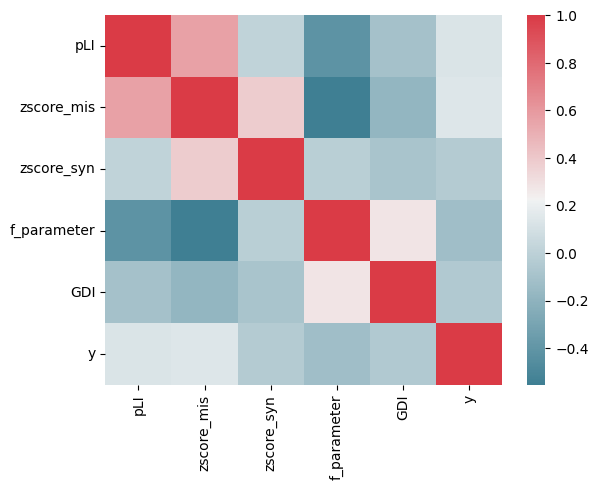

In [18]:
import seaborn as sns
sns.heatmap(corr,
            cmap = sns.diverging_palette(220,10, as_cmap=True),
            xticklabels=corr.columns.values,
            yticklabels=corr.columns.values)

### target = 'pLI'

In [19]:
remove_sex_chrom = False
target_to_use = 'pLI'

nodes2id['GENE'] = nodes2id['GENE'][['GENE_id', 'mapped_id']]
# open the file with the features values 
feat = pd.read_csv(data_processed_path + 'human_genes_features_20230414.tsv', sep = '\t', header = 0)
feat = pd.merge(nodes2id['GENE'], feat, left_on = 'GENE_id', right_on = 'ENSG_ID', how = 'left')
# open the file with the essential vs non_essential, and remove some of them: pseudogene etc.  
# TODO update the essential_file
vitro = pd.read_csv(data_raw_path + 'essentials_invitro_20240214.tsv', sep = '\t', names = ['gene_id'])
list_to_remove = [
    'ENSG00000158483', 'ENSG00000172014', 'ENSG00000180953', 'ENSG00000183148', 'ENSG00000186825',
    'ENSG00000197927', 'ENSG00000198019', 'ENSG00000204677', 'ENSG00000213029', 'ENSG00000232962', 
    'ENSG00000263091', 'ENSG00000276816', 'ENSG00000282827', 'ENSG00000283472', 'SF3B14']
# conversion_df = pd.read_csv('/data-cbl/rnicolle/GRL4DD/data/processed/essentials_conversion_dict_20240216.tsv', header = 0, sep = '\t')
conversion_df = pd.read_csv(data_processed_path + 'essentials_conversion_dict_20240216.tsv', header = 0, sep = '\t')
my_keys = conversion_df['old_ID'].tolist()
my_values = conversion_df['new_ID'].tolist()
conversion_dict = {}
conversion_dict = {my_keys[i]: my_values[i] for i in range(conversion_df.shape[0])}
vitro = vitro.drop(vitro[vitro['gene_id'].isin(list_to_remove)].index, axis = 0)
vitro = vitro.reset_index(drop = True)         
vitro.replace(to_replace=conversion_dict, inplace=True)   
# get the essential/non-essential type for each GENE
feat.loc[:,['type']] = 'non_essential'
feat.loc[feat[feat['GENE_id'].isin(vitro['gene_id'].tolist())].index, 'type'] = 'essential'
# choose the target: 'pLI' (0: haplo-sufficient, 1: haplo-sensitive, ), 'essential' (0: non_essential, 1: essential)
if target_to_use in ['pLI', 'OLIDA', 'proven_SL']:
    feat.loc[feat[feat['pLI'] >= 0.9].index, 'y'] = 1
    feat.loc[feat[feat['pLI'] < 0.9].index, 'y'] = 0
    feat.loc[feat[feat['pLI'].isna()].index, 'y'] = 0
    feat.loc[feat[feat['pLI'] == -1].index, 'y'] = 0
elif target_to_use == 'essential':
    feat.loc[:, 'y'] = 0
    feat.loc[feat[feat['type'] == 'essential'].index, 'y'] = 1
elif target_to_use == 'essential_K562':
    essential = pd.read_csv(data_raw_path + 'essentials_K562.tsv', header = 0, sep = '\t')
    feat['type'] = 'non_essential'
    feat.loc[feat[feat['GENE_id'].isin(essential['ENSG_ID'].tolist())].index, 'type'] = 'essential'
    feat.loc[:, 'y'] = 0
    feat.loc[feat[feat['type'] == 'essential'].index, 'y'] = 1
elif target_to_use == 'essential_A375':
    essential = pd.read_csv(data_raw_path + 'essentials_A375.tsv', header = 0, sep = '\t')
    feat['type'] = 'non_essential'
    feat.loc[feat[feat['GENE_id'].isin(essential['ENSG_ID'].tolist())].index, 'type'] = 'essential'
    feat.loc[:, 'y'] = 0
    feat.loc[feat[feat['type'] == 'essential'].index, 'y'] = 1
elif target_to_use == 'essential_A549':
    essential = pd.read_csv(data_raw_path + 'essentials_A549.tsv', header = 0, sep = '\t')
    feat['type'] = 'non_essential'
    feat.loc[feat[feat['GENE_id'].isin(essential['ENSG_ID'].tolist())].index, 'type'] = 'essential'
    feat.loc[:, 'y'] = 0
    feat.loc[feat[feat['type'] == 'essential'].index, 'y'] = 1
elif target_to_use == 'OMIM':
    omim = pd.read_csv(data_raw_path + 'humans_n2n_OMIM_20250826.tsv', header = 0, sep = '\t')
    feat = feat.merge(omim[['GENE_id', 'target']], how='left', left_on='GENE_id', right_on='GENE_id')
    feat = feat.rename(columns = {'target': 'y'})
else:
    raise Exception(f"Please select either 'pLI' or 'essential' or 'essential_K562' or 'essential_A375' or 'essential_A549' for the target to use.")
# remove sex_chromosom ? TODO
if (remove_sex_chrom == True) and (set(['chrX','chrY']).issubset(set(feat['chrom'].unique().tolist())) == True):
    feat = feat.drop(feat[feat['chrom'].isin(['chrX', 'chrY'])].index, axis = 0)
    feat = feat.drop('chrom', axis = 1)
# some GENES are missing values: get the median value of the GENES of the same class, i.e. haplo-sensitive/sufficient or essential/non_essential
feat = feat.reset_index(drop = True)
dict_0 = feat[feat['y'] == 0].median(axis = 0, skipna = True, numeric_only = True).to_dict()
dict_1 = feat[feat['y'] == 1].median(axis = 0, skipna = True, numeric_only = True).to_dict()
# some GENES with OMIM target have no features at all, they have target -1
# for i in ['zscore_mis','zscore_syn','f_parameter']:
for i in dict_0.keys():
    feat.loc[feat[(feat['y'] == 0) & (feat[i].isna())].index, i] = dict_0[i] 
    feat.loc[feat[(feat['y'] == 1) & (feat[i].isna())].index, i] = dict_1[i] 
if target_to_use == 'OMIM':
    for i in dict_0.keys():
        feat.loc[feat[(feat['y'] == -1) & (feat[i].isna())].index, i] = dict_0[i] 

In [20]:
feat

,GENE_id,mapped_id,ENSG_ID,GeneName,chrom,pLI,loeuf,zscore_mis,zscore_syn,Haploinsufficiency_Score,...,pHI,SCoNeS,f_parameter,shet_det,shet_drift,GDI,ncRVIS,ncGERP,type,y
0,ENSG00000000003,0,ENSG00000000003,TSPAN6,chrX,0.07,0.98,0.59,-0.47,30.0,...,0.140,0.754,0.389514,0.011842,0.009499,396.91909,-0.709543,0.594130,non_essential,0.0
1,ENSG00000000005,1,ENSG00000000005,TNMD,chrX,0.00,0.91,0.86,-0.46,30.0,...,0.548,0.908,0.321257,0.211636,0.173532,34.34833,-0.138825,3.094064,non_essential,0.0
2,ENSG00000000419,2,ENSG00000000419,DPM1,chr20,0.00,0.87,0.38,-1.76,30.0,...,0.582,0.958,0.456396,0.027706,0.019605,228.07250,-0.205840,0.211290,essential,0.0
3,ENSG00000000457,3,ENSG00000000457,SCYL3,chr1,0.28,0.42,0.98,0.71,30.0,...,0.273,0.632,0.524130,0.017412,0.012033,582.74642,-0.406859,0.386676,non_essential,0.0
4,ENSG00000000460,4,ENSG00000000460,C1orf112,chr1,0.00,0.73,0.57,0.89,30.0,...,0.290,0.968,0.435878,0.004870,0.004307,683.38620,0.159304,0.046517,non_essential,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19325,ENSG00000290320,19325,ENSG00000290320,H2BN1,NaN,0.00,1.00,0.48,-0.04,30.0,...,0.290,0.848,0.482830,0.018429,0.012931,228.07250,-0.062194,-0.124894,non_essential,0.0
19326,ENSG00000291237,19326,ENSG00000291237,SOD2,NaN,0.00,1.00,0.48,-0.04,30.0,...,0.740,0.822,0.520319,0.024320,0.016829,2050.40796,1.737933,-0.215227,essential,0.0
19327,ENSG00000291307,19327,ENSG00000291307,POLGARF,NaN,0.00,1.00,0.48,-0.04,30.0,...,0.290,0.848,0.482830,0.018429,0.012931,228.07250,-0.062194,-0.124894,non_essential,0.0
19328,ENSG00000291317,19328,ENSG00000291317,TMEM276,NaN,0.00,1.00,0.48,-0.04,30.0,...,0.290,0.848,0.482830,0.018429,0.012931,228.07250,-0.062194,-0.124894,non_essential,0.0


In [21]:
feat.columns

Index(['GENE_id', 'mapped_id', 'ENSG_ID', 'GeneName', 'chrom', 'pLI', 'loeuf',
       'zscore_mis', 'zscore_syn', 'Haploinsufficiency_Score',
       'Haploinsufficiency_Description', 'Triplosensitivity_Score',
       'Triplosensitivity_Description', 'FUSIL', 'DDD_HI_percentage',
       'known_developmental_disorder_genes', 'RVIS', 'omim_class', 'DOMINO',
       'pHI', 'SCoNeS', 'f_parameter', 'shet_det', 'shet_drift', 'GDI',
       'ncRVIS', 'ncGERP', 'type', 'y'],
      dtype='object')

In [22]:
feat = feat[['pLI', 'zscore_mis', 'zscore_syn', 'f_parameter', 'GDI', 'y']]

In [23]:
feat.columns

Index(['pLI', 'zscore_mis', 'zscore_syn', 'f_parameter', 'GDI', 'y'], dtype='object')

In [24]:
numerical_columns = numerical_columns_selector(feat)
feat[numerical_columns]

,pLI,zscore_mis,zscore_syn,f_parameter,GDI,y
0,0.07,0.59,-0.47,0.389514,396.91909,0.0
1,0.00,0.86,-0.46,0.321257,34.34833,0.0
2,0.00,0.38,-1.76,0.456396,228.07250,0.0
3,0.28,0.98,0.71,0.524130,582.74642,0.0
4,0.00,0.57,0.89,0.435878,683.38620,0.0
...,...,...,...,...,...,...
19325,0.00,0.48,-0.04,0.482830,228.07250,0.0
19326,0.00,0.48,-0.04,0.520319,2050.40796,0.0
19327,0.00,0.48,-0.04,0.482830,228.07250,0.0
19328,0.00,0.48,-0.04,0.482830,228.07250,0.0


In [25]:
corr = feat[numerical_columns].corr()
corr

,pLI,zscore_mis,zscore_syn,f_parameter,GDI,y
pLI,1.000000,0.570903,0.012441,-0.426795,-0.106488,0.821792
zscore_mis,0.570903,1.000000,0.384115,-0.556509,-0.177130,0.524919
zscore_syn,0.012441,0.384115,1.000000,-0.015492,-0.089674,0.001965
f_parameter,-0.426795,-0.556509,-0.015492,1.000000,0.281540,-0.354226
GDI,-0.106488,-0.177130,-0.089674,0.281540,1.000000,-0.068033
y,0.821792,0.524919,0.001965,-0.354226,-0.068033,1.000000


<AxesSubplot:>

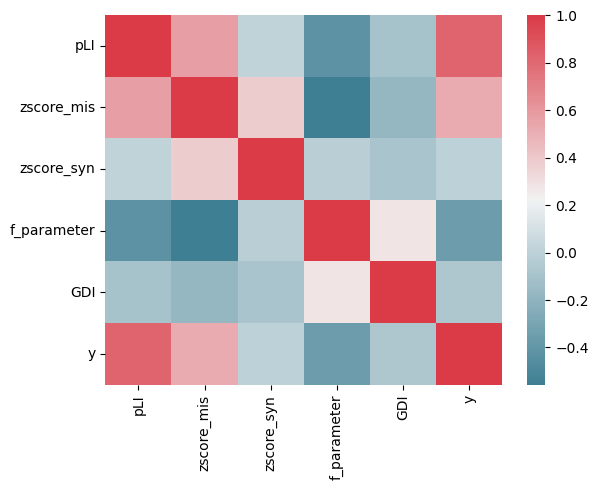

In [26]:
sns.heatmap(corr,
            cmap = sns.diverging_palette(220,10, as_cmap=True),
            xticklabels=corr.columns.values,
            yticklabels=corr.columns.values)

# 19330 genes, threshold = 0.7

In [ ]:
# 19330 if remove Coexp and Neighbour

In [27]:
string_threshold = 700

# open the Human_Knowledge_Graph
string_threshold = 700
net = pd.read_csv(data_processed_path + f'human_knowledge_graph.tsv', sep = '\t', header = 0, dtype = {1: str, 3: str, 4: str})
net = net.drop(net[(net['EdgeType'].isin(['PPI'])) & (net['EdgeScore'] < string_threshold)].index, axis = 0)
net = net.reset_index(drop = True)
# I will not be using these edges,maybe in a future version ? 
edges_to_remove = [
    'CoExp', 'Neighbour', 
    'not_expressed_in', 'DIDA',
    'synthetic_lethal', 'synthetic_non_lethal', 
    'regulatory_proximal', 'regulatory_distal'
    ]
net = net.drop(net[net['EdgeType'].isin(edges_to_remove)].index, axis=0)
net = net.reset_index(drop=True)

all_genes = list(set().union(net[net['node1_type'] == 'GENE']['node1_ID'].unique(), net[net['node2_type'] == 'GENE']['node2_ID'].unique()))
# I could hardcode edges_names, edge_summary eveneutally
edges_names = net['EdgeType'].value_counts().to_dict()
edges_summary = []
for edge_name in edges_names.keys():
    tmp_list = [edge_name, 
                net[net['EdgeType'] == edge_name]['node1_type'].unique()[0], 
                net[net['EdgeType'] == edge_name]['node2_type'].unique()[0], 
                net[net['EdgeType'] == edge_name]['EdgeDirection'].unique()[0], 
                edges_names[edge_name]]
    # create a special case when there are edge_attributes
    # not currently using edges_attributes, but maybe in a future version 
    if sum(net[net['EdgeType'] == edge_name]['EdgeScore'].isna()) == 0:
        tmp_list.append(1)
    else:
        tmp_list.append(0)
    edges_summary.append(tmp_list) 

edges_types = list(set(net['EdgeType'].unique()))
nodes_types = list(set().union(net['node1_type'].unique(),net['node2_type'].unique()))
nodes_types.sort()
nodes_numbers = {}
for node_type in nodes_types:
    nodes_numbers[node_type] = len(set().union(net[net['node1_type'] == node_type]['node1_ID'].unique(), net[net['node2_type'] == node_type]['node2_ID'].unique()))

print(f"nodes_types: {nodes_types}")
print(f"nodes_numbers: {nodes_numbers}")

list_of_edges = net['EdgeType'].unique().tolist()

def Get_df_for_nodetype_id(df: pd.DataFrame, node_type : str) -> pd.DataFrame:
    node_type_list = list(set().union(df[df['node1_type'] == node_type]['node1_ID'].unique(), df[df['node2_type'] == node_type]['node2_ID'].unique()))
    node_type_list.sort()
    node_type_array = np.asarray(node_type_list)
    new_df = pd.DataFrame(data = {
        f"{node_type}_id": node_type_array,
        "mapped_id": pd.RangeIndex(len(node_type_array))
    })
    return(new_df)

nodes2id = {}
for type_of_node in nodes_types:
    nodes2id[type_of_node] = Get_df_for_nodetype_id(net, type_of_node)

edges_to_nodes = {}
for type_of_edge in edges_summary:
    edges_to_nodes[type_of_edge[0]] = [type_of_edge[1], type_of_edge[2]] 

nodes_types: ['ANATOMY', 'BP', 'CC', 'GENE', 'MF']
nodes_numbers: {'ANATOMY': 14337, 'BP': 27993, 'CC': 4039, 'GENE': 19330, 'MF': 11271}


### function_target

In [28]:
features = 'basic'

# create columns selectors
numerical_columns_selector = selector(dtype_exclude = object)
categorical_columns_selector = selector(dtype_include = object)
numerical_preprocessor = StandardScaler()
categorical_preprocessor = OneHotEncoder(handle_unknown="ignore")

def get_strict_target_tensors(target_to_use: str = 'essential', features_to_use: str = 'strict', remove_sex_chrom:bool = False):
    nodes2id['GENE'] = nodes2id['GENE'][['GENE_id', 'mapped_id']]
    # open the file with the features values 
    feat = pd.read_csv(data_processed_path + 'human_genes_features_20230414.tsv', sep = '\t', header = 0)
    feat = pd.merge(nodes2id['GENE'], feat, left_on = 'GENE_id', right_on = 'ENSG_ID', how = 'left')
    # open the file with the essential vs non_essential, and remove some of them: pseudogene etc.  
    # TODO update the essential_file
    vitro = pd.read_csv(data_raw_path + 'essentials_invitro_20240214.tsv', sep = '\t', names = ['gene_id'])
    list_to_remove = [
        'ENSG00000158483', 'ENSG00000172014', 'ENSG00000180953', 'ENSG00000183148', 'ENSG00000186825',
        'ENSG00000197927', 'ENSG00000198019', 'ENSG00000204677', 'ENSG00000213029', 'ENSG00000232962', 
        'ENSG00000263091', 'ENSG00000276816', 'ENSG00000282827', 'ENSG00000283472', 'SF3B14']
    # conversion_df = pd.read_csv('/data-cbl/rnicolle/GRL4DD/data/processed/essentials_conversion_dict_20240216.tsv', header = 0, sep = '\t')
    conversion_df = pd.read_csv(data_processed_path + 'essentials_conversion_dict_20240216.tsv', header = 0, sep = '\t')
    my_keys = conversion_df['old_ID'].tolist()
    my_values = conversion_df['new_ID'].tolist()
    conversion_dict = {}
    conversion_dict = {my_keys[i]: my_values[i] for i in range(conversion_df.shape[0])}
    vitro = vitro.drop(vitro[vitro['gene_id'].isin(list_to_remove)].index, axis = 0)
    vitro = vitro.reset_index(drop = True)         
    vitro.replace(to_replace=conversion_dict, inplace=True)   
    # get the essential/non-essential type for each GENE
    feat.loc[:,['type']] = 'non_essential'
    feat.loc[feat[feat['GENE_id'].isin(vitro['gene_id'].tolist())].index, 'type'] = 'essential'
    # choose the target: 'pLI' (0: haplo-sufficient, 1: haplo-sensitive, ), 'essential' (0: non_essential, 1: essential)
    if target_to_use in ['pLI', 'OLIDA', 'proven_SL']:
        feat.loc[feat[feat['pLI'] >= 0.9].index, 'y'] = 1
        feat.loc[feat[feat['pLI'] < 0.9].index, 'y'] = 0
        feat.loc[feat[feat['pLI'].isna()].index, 'y'] = 0
        feat.loc[feat[feat['pLI'] == -1].index, 'y'] = 0
    elif target_to_use == 'essential':
        feat.loc[:, 'y'] = 0
        feat.loc[feat[feat['type'] == 'essential'].index, 'y'] = 1
    elif target_to_use == 'essential_K562':
        essential = pd.read_csv(data_raw_path + 'essentials_K562.tsv', header = 0, sep = '\t')
        feat['type'] = 'non_essential'
        feat.loc[feat[feat['GENE_id'].isin(essential['ENSG_ID'].tolist())].index, 'type'] = 'essential'
        feat.loc[:, 'y'] = 0
        feat.loc[feat[feat['type'] == 'essential'].index, 'y'] = 1
    elif target_to_use == 'essential_A375':
        essential = pd.read_csv(data_raw_path + 'essentials_A375.tsv', header = 0, sep = '\t')
        feat['type'] = 'non_essential'
        feat.loc[feat[feat['GENE_id'].isin(essential['ENSG_ID'].tolist())].index, 'type'] = 'essential'
        feat.loc[:, 'y'] = 0
        feat.loc[feat[feat['type'] == 'essential'].index, 'y'] = 1
    elif target_to_use == 'essential_A549':
        essential = pd.read_csv(data_raw_path + 'essentials_A549.tsv', header = 0, sep = '\t')
        feat['type'] = 'non_essential'
        feat.loc[feat[feat['GENE_id'].isin(essential['ENSG_ID'].tolist())].index, 'type'] = 'essential'
        feat.loc[:, 'y'] = 0
        feat.loc[feat[feat['type'] == 'essential'].index, 'y'] = 1
    elif target_to_use == 'OMIM':
        omim = pd.read_csv(data_raw_path + 'humans_n2n_OMIM_20250826.tsv', header = 0, sep = '\t')
        feat = feat.merge(omim[['GENE_id', 'target']], how='left', left_on='GENE_id', right_on='GENE_id')
        feat = feat.rename(columns = {'target': 'y'})
    else:
        raise Exception(f"Please select either 'pLI' or 'essential' or 'essential_K562' or 'essential_A375' or 'essential_A549' for the target to use.")
    # remove sex_chromosom ? TODO
    if (remove_sex_chrom == True) and (set(['chrX','chrY']).issubset(set(feat['chrom'].unique().tolist())) == True):
        feat = feat.drop(feat[feat['chrom'].isin(['chrX', 'chrY'])].index, axis = 0)
        feat = feat.drop('chrom', axis = 1)
    # some GENES are missing values: get the median value of the GENES of the same class, i.e. haplo-sensitive/sufficient or essential/non_essential
    feat = feat.reset_index(drop = True)
    dict_0 = feat[feat['y'] == 0].median(axis = 0, skipna = True, numeric_only = True).to_dict()
    dict_1 = feat[feat['y'] == 1].median(axis = 0, skipna = True, numeric_only = True).to_dict()
    # some GENES with OMIM target have no features at all, they have target -1
    # for i in ['zscore_mis','zscore_syn','f_parameter']:
    for i in dict_0.keys():
        feat.loc[feat[(feat['y'] == 0) & (feat[i].isna())].index, i] = dict_0[i] 
        feat.loc[feat[(feat['y'] == 1) & (feat[i].isna())].index, i] = dict_1[i] 
    if target_to_use == 'OMIM':
        for i in dict_0.keys():
            feat.loc[feat[(feat['y'] == -1) & (feat[i].isna())].index, i] = dict_0[i] 

    if features_to_use in ['strict', 'basic']:
        feat = feat.drop([
        'GENE_id', 'mapped_id', 'ENSG_ID', 'GeneName', 'chrom', 'loeuf',
        'Haploinsufficiency_Score', 'Haploinsufficiency_Description',
        'Triplosensitivity_Score', 'Triplosensitivity_Description', 'omim_class', 'known_developmental_disorder_genes',
        'DDD_HI_percentage', 'RVIS', 'DOMINO', 'pHI', 'SCoNeS', 'shet_det', 'shet_drift', #'GDI', 
        'ncRVIS', 'ncGERP', 'type'], axis = 1)
    elif features_to_use == 'large':
        feat = feat.drop([
        'GENE_id', 'mapped_id', 'ENSG_ID', 'GeneName', 'chrom', #'loeuf',
        'Haploinsufficiency_Score', 'Haploinsufficiency_Description',
        'Triplosensitivity_Score', 'Triplosensitivity_Description', 'omim_class', 'known_developmental_disorder_genes',
        'DDD_HI_percentage', 
        # 'RVIS', 
        'DOMINO', 'pHI', 
        # 'SCoNeS', 'shet_det', 'shet_drift', #'GDI', 
        'ncRVIS', 'ncGERP', 'type'], axis = 1)
    
    if target_to_use in ['essential', 'essential_K562', 'essential_A375', 'essential_A549'] or features_to_use == 'basic':
        feat = feat.drop('FUSIL', axis = 1) # FUSIL is highly correlated to essentiality
    else: # target_to_use == 'pLI' = keep FUSIL category
        categorical_columns = ['FUSIL']
        feat = pd.get_dummies(feat, columns = categorical_columns, dtype = float)
    feat = feat.drop('pLI', axis = 1)
    numerical_columns = numerical_columns_selector(feat)
    numerical_columns.remove('y')
    feat[numerical_columns] = StandardScaler().fit_transform(feat[numerical_columns])
    gene_feat = feat.copy()
    ### get tensors
    target_tensor = torch.from_numpy(gene_feat.y.values)
    gene_feat = feat.drop('y', axis = 1)
    gene_feat_tensor = torch.from_numpy(gene_feat.values)
    
    return gene_feat_tensor, target_tensor, feat 

_, _, dfeat = get_strict_target_tensors(target_to_use='essential', features_to_use='basic')

In [29]:
dfeat

,zscore_mis,zscore_syn,f_parameter,GDI,y
0,-0.165279,-0.227964,-0.691348,-0.267739,0
1,0.048602,-0.220098,-1.245063,-0.459383,0
2,-0.331631,-1.242591,-0.148785,-0.428285,1
3,0.143660,0.700145,0.400692,-0.169516,0
4,-0.181122,0.841721,-0.315230,-0.116321,0
...,...,...,...,...,...
19325,-0.133593,0.125976,-0.045295,-0.362680,0
19326,0.222876,0.007996,0.369782,0.606246,1
19327,-0.133593,0.125976,-0.045295,-0.362680,0
19328,-0.133593,0.125976,-0.045295,-0.362680,0


In [30]:
dfeat['y'].value_counts()

y
0    17341
1     1989
Name: count, dtype: int64

### target_essential

In [32]:
target_to_use = 'essential'

nodes2id['GENE'] = nodes2id['GENE'][['GENE_id', 'mapped_id']]
# open the file with the features values 
feat = pd.read_csv(data_processed_path + 'human_genes_features_20230414.tsv', sep = '\t', header = 0)
feat = pd.merge(nodes2id['GENE'], feat, left_on = 'GENE_id', right_on = 'ENSG_ID', how = 'left')
# open the file with the essential vs non_essential, and remove some of them: pseudogene etc.  
# TODO update the essential_file
vitro = pd.read_csv(data_raw_path + 'essentials_invitro_20240214.tsv', sep = '\t', names = ['gene_id'])
list_to_remove = [
    'ENSG00000158483', 'ENSG00000172014', 'ENSG00000180953', 'ENSG00000183148', 'ENSG00000186825',
    'ENSG00000197927', 'ENSG00000198019', 'ENSG00000204677', 'ENSG00000213029', 'ENSG00000232962', 
    'ENSG00000263091', 'ENSG00000276816', 'ENSG00000282827', 'ENSG00000283472', 'SF3B14']
# conversion_df = pd.read_csv('/data-cbl/rnicolle/GRL4DD/data/processed/essentials_conversion_dict_20240216.tsv', header = 0, sep = '\t')
conversion_df = pd.read_csv(data_processed_path + 'essentials_conversion_dict_20240216.tsv', header = 0, sep = '\t')
my_keys = conversion_df['old_ID'].tolist()
my_values = conversion_df['new_ID'].tolist()
conversion_dict = {}
conversion_dict = {my_keys[i]: my_values[i] for i in range(conversion_df.shape[0])}
vitro = vitro.drop(vitro[vitro['gene_id'].isin(list_to_remove)].index, axis = 0)
vitro = vitro.reset_index(drop = True)         
vitro.replace(to_replace=conversion_dict, inplace=True)   
# get the essential/non-essential type for each GENE
feat.loc[:,['type']] = 'non_essential'
feat.loc[feat[feat['GENE_id'].isin(vitro['gene_id'].tolist())].index, 'type'] = 'essential'
# choose the target: 'pLI' (0: haplo-sufficient, 1: haplo-sensitive, ), 'essential' (0: non_essential, 1: essential)
if target_to_use in ['pLI', 'OLIDA', 'proven_SL']:
    feat.loc[feat[feat['pLI'] >= 0.9].index, 'y'] = 1
    feat.loc[feat[feat['pLI'] < 0.9].index, 'y'] = 0
    feat.loc[feat[feat['pLI'].isna()].index, 'y'] = 0
    feat.loc[feat[feat['pLI'] == -1].index, 'y'] = 0
elif target_to_use == 'essential':
    feat.loc[:, 'y'] = 0
    feat.loc[feat[feat['type'] == 'essential'].index, 'y'] = 1
elif target_to_use == 'essential_K562':
    essential = pd.read_csv(data_raw_path + 'essentials_K562.tsv', header = 0, sep = '\t')
    feat['type'] = 'non_essential'
    feat.loc[feat[feat['GENE_id'].isin(essential['ENSG_ID'].tolist())].index, 'type'] = 'essential'
    feat.loc[:, 'y'] = 0
    feat.loc[feat[feat['type'] == 'essential'].index, 'y'] = 1
elif target_to_use == 'essential_A375':
    essential = pd.read_csv(data_raw_path + 'essentials_A375.tsv', header = 0, sep = '\t')
    feat['type'] = 'non_essential'
    feat.loc[feat[feat['GENE_id'].isin(essential['ENSG_ID'].tolist())].index, 'type'] = 'essential'
    feat.loc[:, 'y'] = 0
    feat.loc[feat[feat['type'] == 'essential'].index, 'y'] = 1
elif target_to_use == 'essential_A549':
    essential = pd.read_csv(data_raw_path + 'essentials_A549.tsv', header = 0, sep = '\t')
    feat['type'] = 'non_essential'
    feat.loc[feat[feat['GENE_id'].isin(essential['ENSG_ID'].tolist())].index, 'type'] = 'essential'
    feat.loc[:, 'y'] = 0
    feat.loc[feat[feat['type'] == 'essential'].index, 'y'] = 1
elif target_to_use == 'OMIM':
    omim = pd.read_csv(data_raw_path + 'humans_n2n_OMIM_20250826.tsv', header = 0, sep = '\t')
    feat = feat.merge(omim[['GENE_id', 'target']], how='left', left_on='GENE_id', right_on='GENE_id')
    feat = feat.rename(columns = {'target': 'y'})
else:
    raise Exception(f"Please select either 'pLI' or 'essential' or 'essential_K562' or 'essential_A375' or 'essential_A549' for the target to use.")

nodes = feat[['GENE_id', 'mapped_id', 'type', 'y']]

print(len(nodes))
essential_index = nodes[nodes['type'] == 'essential'].index
non_essential_index = nodes[nodes['type'] == 'non_essential'].index

print(int(len(essential_index) * 0.70))
print(int(len(non_essential_index) * 0.70))

19330
1392
12138


### split_seeds

In [34]:
def create_split_seed(df: pd.DataFrame, number: int = 0, train_ratio: float = 0.70) -> pd.Series:
    random.seed(number)
    name = f"seed_{number}"
    
    essential_index = list(nodes[nodes['type'] == 'essential'].index)
    non_essential_index = list(nodes[nodes['type'] == 'non_essential'].index)
    
    train_pos_selected = random.sample(essential_index, int(len(essential_index) * train_ratio))
    train_pos_selected.sort()
    train_neg_selected = random.sample(non_essential_index, int(len(non_essential_index) * train_ratio))
    train_neg_selected.sort()
    
    ser = pd.Series(data = ['test'] * len(df), name = name)
    ser.iloc[train_pos_selected] = 'train'
    ser.iloc[train_neg_selected] = 'train'
    
    return ser

In [35]:
splits_seeds = pd.concat([create_split_seed(df = nodes, number = i, train_ratio = 0.70) for i in range(1,31)], axis = 1)

In [37]:
splits_seeds

,seed_1,seed_2,seed_3,seed_4,seed_5,seed_6,seed_7,seed_8,seed_9,seed_10,...,seed_21,seed_22,seed_23,seed_24,seed_25,seed_26,seed_27,seed_28,seed_29,seed_30
0,train,train,train,train,train,train,test,test,test,train,...,train,train,train,test,train,train,train,train,test,train
1,test,train,train,train,train,train,train,train,train,test,...,train,test,train,test,train,test,train,train,train,train
2,test,test,test,train,train,train,train,train,test,train,...,test,train,train,train,test,train,train,train,train,train
3,test,train,train,train,train,test,train,train,train,test,...,train,test,test,train,train,train,train,train,test,train
4,train,train,test,test,train,train,test,train,train,train,...,train,test,train,train,train,test,train,test,train,test
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19325,test,test,test,train,train,train,train,test,train,test,...,train,train,train,train,test,test,train,train,train,train
19326,train,test,test,train,test,train,test,train,train,train,...,train,train,train,test,test,test,test,test,train,train
19327,train,train,train,test,train,train,train,test,train,test,...,train,test,test,train,train,train,test,train,train,train
19328,train,train,test,test,train,test,test,train,test,train,...,train,train,test,train,test,train,train,train,train,train


In [61]:
splits_seeds.to_csv(
    data_processed_path + 'humans_n2n_19330_splits_seeds.tsv',
    header = True, index = False, sep = '\t', mode = 'x')

# splits_seeds = pd.read_csv(
#     data_processed_path + '/data-cbl/rnicolle/GRL4DD/data/processed/humans_n2n_19330_splits_seeds.tsv',
#     sep = '\t', header = 0
# )

In [62]:
nodes = nodes[['GENE_id', 'mapped_id', 'type', 'y']]

In [42]:
def create_cross_val_for_split_seed(nodes: pd.DataFrame, split_seed: int = 1, number: int = 42) -> pd.Series:
    random.seed(number)
    col_to_use = f"seed_{split_seed}"
    splits_seeds = pd.read_csv(
        data_processed_path + 'humans_n2n_19330_splits_seeds.tsv',
        sep = '\t', header = 0
    )
    nodes = pd.concat([nodes, splits_seeds[col_to_use]], axis = 1)
    
    essential_index = list(nodes[(nodes['type'] == 'essential') & (nodes[col_to_use] == 'train')].index)
    non_essential_index = list(nodes[(nodes['type'] == 'non_essential') & (nodes[col_to_use] == 'train')].index)
    # https://stackoverflow.com/questions/3352737/how-to-randomly-partition-a-list-into-n-nearly-equal-parts
    essential_folds = [essential_index[i::10] for i in range(10)]
    non_essential_folds = [non_essential_index[i::10] for i in range(10)]
    
    ser = pd.Series(data = ['leave_out_test'] * len(nodes), name = f'cv_seed_{split_seed}')
    
    for i in range(len(essential_folds)):
        essential = essential_folds[i]
        essential.sort()
        non_essential = non_essential_folds[i]
        non_essential.sort()
        ser.iloc[essential] = f'cv_{i+1}'
        ser.iloc[non_essential] = f'cv_{i+1}'
    
    return ser

In [43]:
df = pd.concat([create_cross_val_for_split_seed(nodes = nodes, split_seed = i, number = 42) for i in range(1,31)], axis = 1)

In [44]:
df

,cv_seed_1,cv_seed_2,cv_seed_3,cv_seed_4,cv_seed_5,cv_seed_6,cv_seed_7,cv_seed_8,cv_seed_9,cv_seed_10,...,cv_seed_21,cv_seed_22,cv_seed_23,cv_seed_24,cv_seed_25,cv_seed_26,cv_seed_27,cv_seed_28,cv_seed_29,cv_seed_30
0,cv_1,cv_1,cv_1,cv_1,cv_1,cv_1,leave_out_test,leave_out_test,leave_out_test,cv_1,...,cv_1,cv_1,cv_1,leave_out_test,cv_1,cv_1,cv_1,cv_1,leave_out_test,cv_1
1,leave_out_test,cv_2,cv_2,cv_2,cv_2,cv_2,cv_1,cv_1,cv_1,leave_out_test,...,cv_2,leave_out_test,cv_2,leave_out_test,cv_2,leave_out_test,cv_2,cv_2,cv_1,cv_2
2,leave_out_test,leave_out_test,leave_out_test,cv_1,cv_1,cv_1,cv_1,cv_1,leave_out_test,cv_1,...,leave_out_test,cv_1,cv_1,cv_1,leave_out_test,cv_1,cv_1,cv_1,cv_1,cv_1
3,leave_out_test,cv_3,cv_3,cv_3,cv_3,leave_out_test,cv_2,cv_2,cv_2,leave_out_test,...,cv_3,leave_out_test,leave_out_test,cv_1,cv_3,cv_2,cv_3,cv_3,leave_out_test,cv_3
4,cv_2,cv_4,leave_out_test,leave_out_test,cv_4,cv_3,leave_out_test,cv_3,cv_3,cv_2,...,cv_4,leave_out_test,cv_3,cv_2,cv_4,leave_out_test,cv_4,leave_out_test,cv_2,leave_out_test
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19325,leave_out_test,leave_out_test,leave_out_test,cv_7,cv_5,cv_6,cv_7,leave_out_test,cv_6,leave_out_test,...,cv_5,cv_6,cv_8,cv_6,leave_out_test,leave_out_test,cv_6,cv_6,cv_6,cv_5
19326,cv_2,leave_out_test,leave_out_test,cv_2,leave_out_test,cv_2,leave_out_test,cv_2,cv_2,cv_2,...,cv_2,cv_2,cv_2,leave_out_test,leave_out_test,leave_out_test,leave_out_test,leave_out_test,cv_2,cv_2
19327,cv_6,cv_6,cv_7,leave_out_test,cv_6,cv_7,cv_8,leave_out_test,cv_7,leave_out_test,...,cv_6,leave_out_test,leave_out_test,cv_7,cv_7,cv_6,leave_out_test,cv_7,cv_7,cv_6
19328,cv_7,cv_7,leave_out_test,leave_out_test,cv_7,leave_out_test,leave_out_test,cv_8,leave_out_test,cv_7,...,cv_7,cv_7,leave_out_test,cv_8,leave_out_test,cv_7,cv_7,cv_8,cv_8,cv_7


In [45]:
for i in range(1,31):
    print(i)
    print(df[f'cv_seed_{i}'].value_counts())
    print('xxx' * 20)

1
cv_seed_1
leave_out_test    5800
cv_1              1354
cv_2              1354
cv_3              1353
cv_4              1353
cv_5              1353
cv_6              1353
cv_7              1353
cv_8              1353
cv_9              1352
cv_10             1352
Name: count, dtype: int64
xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx
2
cv_seed_2
leave_out_test    5800
cv_1              1354
cv_2              1354
cv_3              1353
cv_4              1353
cv_5              1353
cv_6              1353
cv_7              1353
cv_8              1353
cv_9              1352
cv_10             1352
Name: count, dtype: int64
xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx
3
cv_seed_3
leave_out_test    5800
cv_1              1354
cv_2              1354
cv_3              1353
cv_4              1353
cv_5              1353
cv_6              1353
cv_7              1353
cv_8              1353
cv_9              1352
cv_10             1352
Name: count, dtype: int64
xxxxx

In [67]:
df.to_csv(
    data_processed_path + 'humans_n2n_19330_splits_seeds_cv.tsv',
          sep = '\t', header = True, index = False, mode = 'x')

# cv_folds = pd.read_csv(
#         data_processed_path + 'humans_n2n_19330_splits_seeds_cv.tsv',
#         sep = '\t', header = 0)

In [46]:
df

,cv_seed_1,cv_seed_2,cv_seed_3,cv_seed_4,cv_seed_5,cv_seed_6,cv_seed_7,cv_seed_8,cv_seed_9,cv_seed_10,...,cv_seed_21,cv_seed_22,cv_seed_23,cv_seed_24,cv_seed_25,cv_seed_26,cv_seed_27,cv_seed_28,cv_seed_29,cv_seed_30
0,cv_1,cv_1,cv_1,cv_1,cv_1,cv_1,leave_out_test,leave_out_test,leave_out_test,cv_1,...,cv_1,cv_1,cv_1,leave_out_test,cv_1,cv_1,cv_1,cv_1,leave_out_test,cv_1
1,leave_out_test,cv_2,cv_2,cv_2,cv_2,cv_2,cv_1,cv_1,cv_1,leave_out_test,...,cv_2,leave_out_test,cv_2,leave_out_test,cv_2,leave_out_test,cv_2,cv_2,cv_1,cv_2
2,leave_out_test,leave_out_test,leave_out_test,cv_1,cv_1,cv_1,cv_1,cv_1,leave_out_test,cv_1,...,leave_out_test,cv_1,cv_1,cv_1,leave_out_test,cv_1,cv_1,cv_1,cv_1,cv_1
3,leave_out_test,cv_3,cv_3,cv_3,cv_3,leave_out_test,cv_2,cv_2,cv_2,leave_out_test,...,cv_3,leave_out_test,leave_out_test,cv_1,cv_3,cv_2,cv_3,cv_3,leave_out_test,cv_3
4,cv_2,cv_4,leave_out_test,leave_out_test,cv_4,cv_3,leave_out_test,cv_3,cv_3,cv_2,...,cv_4,leave_out_test,cv_3,cv_2,cv_4,leave_out_test,cv_4,leave_out_test,cv_2,leave_out_test
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19325,leave_out_test,leave_out_test,leave_out_test,cv_7,cv_5,cv_6,cv_7,leave_out_test,cv_6,leave_out_test,...,cv_5,cv_6,cv_8,cv_6,leave_out_test,leave_out_test,cv_6,cv_6,cv_6,cv_5
19326,cv_2,leave_out_test,leave_out_test,cv_2,leave_out_test,cv_2,leave_out_test,cv_2,cv_2,cv_2,...,cv_2,cv_2,cv_2,leave_out_test,leave_out_test,leave_out_test,leave_out_test,leave_out_test,cv_2,cv_2
19327,cv_6,cv_6,cv_7,leave_out_test,cv_6,cv_7,cv_8,leave_out_test,cv_7,leave_out_test,...,cv_6,leave_out_test,leave_out_test,cv_7,cv_7,cv_6,leave_out_test,cv_7,cv_7,cv_6
19328,cv_7,cv_7,leave_out_test,leave_out_test,cv_7,leave_out_test,leave_out_test,cv_8,leave_out_test,cv_7,...,cv_7,cv_7,leave_out_test,cv_8,leave_out_test,cv_7,cv_7,cv_8,cv_8,cv_7


# 'pLI'

In [112]:
string_threshold = 700

# open the Human_Knowledge_Graph
net = pd.read_csv(data_processed_path + f'human_knowledge_graph.tsv', sep = '\t', header = 0, dtype = {1: str, 3: str, 4: str})
net = net.drop(net[(net['EdgeType'].isin(['PPI'])) & (net['EdgeScore'] < string_threshold)].index, axis = 0)
net = net.reset_index(drop = True)
# I will not be using these edges,maybe in a future version ? 
edges_to_remove = [
    'CoExp', 'Neighbour', 
    'not_expressed_in', 'DIDA',
    'synthetic_lethal', 'synthetic_non_lethal', 
    'regulatory_proximal', 'regulatory_distal'
    ]
net = net.drop(net[net['EdgeType'].isin(edges_to_remove)].index, axis=0)
net = net.reset_index(drop=True)

all_genes = list(set().union(net[net['node1_type'] == 'GENE']['node1_ID'].unique(), net[net['node2_type'] == 'GENE']['node2_ID'].unique()))
# I could hardcode edges_names, edge_summary eveneutally
edges_names = net['EdgeType'].value_counts().to_dict()
edges_summary = []
for edge_name in edges_names.keys():
    tmp_list = [edge_name, 
                net[net['EdgeType'] == edge_name]['node1_type'].unique()[0], 
                net[net['EdgeType'] == edge_name]['node2_type'].unique()[0], 
                net[net['EdgeType'] == edge_name]['EdgeDirection'].unique()[0], 
                edges_names[edge_name]]
    # create a special case when there are edge_attributes
    # not currently using edges_attributes, but maybe in a future version 
    if sum(net[net['EdgeType'] == edge_name]['EdgeScore'].isna()) == 0:
        tmp_list.append(1)
    else:
        tmp_list.append(0)
    edges_summary.append(tmp_list) 

edges_types = list(set(net['EdgeType'].unique()))
nodes_types = list(set().union(net['node1_type'].unique(),net['node2_type'].unique()))
nodes_types.sort()
nodes_numbers = {}
for node_type in nodes_types:
    nodes_numbers[node_type] = len(set().union(net[net['node1_type'] == node_type]['node1_ID'].unique(), net[net['node2_type'] == node_type]['node2_ID'].unique()))

print(f"nodes_types: {nodes_types}")
print(f"nodes_numbers: {nodes_numbers}")

list_of_edges = net['EdgeType'].unique().tolist()

def Get_df_for_nodetype_id(df: pd.DataFrame, node_type : str) -> pd.DataFrame:
    node_type_list = list(set().union(df[df['node1_type'] == node_type]['node1_ID'].unique(), df[df['node2_type'] == node_type]['node2_ID'].unique()))
    node_type_list.sort()
    node_type_array = np.asarray(node_type_list)
    new_df = pd.DataFrame(data = {
        f"{node_type}_id": node_type_array,
        "mapped_id": pd.RangeIndex(len(node_type_array))
    })
    return(new_df)

nodes2id = {}
for type_of_node in nodes_types:
    nodes2id[type_of_node] = Get_df_for_nodetype_id(net, type_of_node)

edges_to_nodes = {}
for type_of_edge in edges_summary:
    edges_to_nodes[type_of_edge[0]] = [type_of_edge[1], type_of_edge[2]] 

nodes_types: ['ANATOMY', 'BP', 'CC', 'GENE', 'MF']
nodes_numbers: {'ANATOMY': 14337, 'BP': 27993, 'CC': 4039, 'GENE': 19330, 'MF': 11271}


## function_target

In [17]:
grl4dd_path = '/data-cbl/rnicolle/GRL4DD/'

In [11]:
def get_strict_target_tensors(target_to_use: str = 'essential', remove_sex_chrom:bool = False):
    # update, debug, Romain, banane
    nodes2id['GENE'] = nodes2id['GENE'][['GENE_id', 'mapped_id']]
    # open the file with the features values 
    feat = pd.read_csv(grl4dd_path+'data/processed/GRL4DD_feat_chrom_20230414.tsv', sep = '\t', header = 0)
    feat = pd.merge(nodes2id['GENE'], feat, left_on = 'GENE_id', right_on = 'ENSG_ID', how = 'left')
    # open the file with the essential vs non_essential, and remove some of them: pseudogene etc.  
    # vitro = pd.read_csv('/data-cbl/rnicolle/GRL4DD/data/raw/essentials_invitro_20240214.tsv', sep = '\t', names = ['gene_id'])
    vitro = pd.read_csv(grl4dd_path+'data/raw/essentials_invitro_20240214.tsv', sep = '\t', names = ['gene_id'])
    list_to_remove = [
        'ENSG00000158483', 'ENSG00000172014', 'ENSG00000180953', 'ENSG00000183148', 'ENSG00000186825',
        'ENSG00000197927', 'ENSG00000198019', 'ENSG00000204677', 'ENSG00000213029', 'ENSG00000232962', 
        'ENSG00000263091', 'ENSG00000276816', 'ENSG00000282827', 'ENSG00000283472', 'SF3B14']
    # conversion_df = pd.read_csv('/data-cbl/rnicolle/GRL4DD/data/processed/essentials_conversion_dict_20240216.tsv', header = 0, sep = '\t')
    conversion_df = pd.read_csv(grl4dd_path+'data/processed/essentials_conversion_dict_20240216.tsv', header = 0, sep = '\t')
    my_keys = conversion_df['old_ID'].tolist()
    my_values = conversion_df['new_ID'].tolist()
    conversion_dict = {}
    conversion_dict = {my_keys[i]: my_values[i] for i in range(conversion_df.shape[0])}
    for gene in list_to_remove:
        vitro = vitro.drop(vitro[vitro['gene_id'] == gene].index, axis = 0)
    vitro = vitro.reset_index(drop = True)         
    vitro.replace(to_replace=conversion_dict, inplace=True)   
    # get the essential/non-essential type for each GENE
    feat.loc[:,['type']] = 'non_essential'
    feat.loc[feat[feat['GENE_id'].isin(vitro['gene_id'].tolist())].index, 'type'] = 'essential'
    # choose the target: 'pLI' (0: haplo-sufficient, 1: haplo-sensitive, ), 'essential' (0: non_essential, 1: essential)
    if target_to_use in ['pLI', 'OLIDA', 'proven_SL']:
        feat.loc[feat[feat.pLI >= 0.9].index, 'y'] = 1
        feat.loc[feat[feat.pLI < 0.9].index, 'y'] = 0
        feat.loc[feat[feat.pLI.isna()].index, 'y'] = 0
        feat.loc[feat[feat.pLI == -1].index, 'y'] = 0
    elif target_to_use == 'essential':
        feat.loc[:, 'y'] = 0
        feat.loc[feat[feat['type'] == 'essential'].index, 'y'] = 1
    elif target_to_use == 'essential_K562':
        # essential = pd.read_csv('/data-cbl/rnicolle/GRL4DD/data/raw/essentials_k562_20250402.tsv', header = 0, sep = '\t')
        essential = pd.read_csv(grl4dd_path+'data/raw/essentials_k562_20250402.tsv', header = 0, sep = '\t')
        feat['type'] = 'non_essential'
        feat.loc[feat[feat['GENE_id'].isin(essential['ENSG_ID'].tolist())].index, 'type'] = 'essential'
        feat.loc[:, 'y'] = 0
        feat.loc[feat[feat['type'] == 'essential'].index, 'y'] = 1
    elif target_to_use == 'essential_A375':
        # essential = pd.read_csv('/data-cbl/rnicolle/GRL4DD/data/raw/essentials_a375_20250417.tsv', header = 0, sep = '\t')
        essential = pd.read_csv(grl4dd_path+'data/raw/essentials_a375_20250417.tsv', header = 0, sep = '\t')
        feat['type'] = 'non_essential'
        feat.loc[feat[feat['GENE_id'].isin(essential['ENSG_ID'].tolist())].index, 'type'] = 'essential'
        feat.loc[:, 'y'] = 0
        feat.loc[feat[feat['type'] == 'essential'].index, 'y'] = 1
    elif target_to_use == 'essential_A549':
        # essential = pd.read_csv('/data-cbl/rnicolle/GRL4DD/data/raw/essentials_a549_20250417.tsv', header = 0, sep = '\t')
        essential = pd.read_csv(grl4dd_path+'data/raw/essentials_a549_20250417.tsv', header = 0, sep = '\t')
        feat['type'] = 'non_essential'
        feat.loc[feat[feat['GENE_id'].isin(essential['ENSG_ID'].tolist())].index, 'type'] = 'essential'
        feat.loc[:, 'y'] = 0
        feat.loc[feat[feat['type'] == 'essential'].index, 'y'] = 1
    elif target_to_use == 'essential_5000':
        # essential = pd.read_csv('/data-cbl/rnicolle/GRL4DD/data/processed/20250220_essential_genes_Funk_5000.tsv', header = 0, sep = '\t')
        essential = pd.read_csv(grl4dd_path+'data/processed/20250220_essential_genes_Funk_5000.tsv', header = 0, sep = '\t')
        feat['type'] = 'non_essential'
        feat.loc[feat[feat['GENE_id'].isin(essential['ENSG_ID'].tolist())].index, 'type'] = 'essential'
        feat.loc[:, 'y'] = 0
        feat.loc[feat[feat['type'] == 'essential'].index, 'y'] = 1
    else:
        raise Exception(f"Please select either 'pLI' or 'essential' or 'essential_5000 for the target to use.")
    # remove sex_chromosom ? 
    if (remove_sex_chrom == True) and (set(['chrX','chrY']).issubset(set(feat.chrom.unique().tolist())) == True):
        feat = feat.drop(feat[feat.chrom.isin(['chrX', 'chrY'])].index, axis = 0)
        feat = feat.drop('chrom', axis = 1)
    # some GENES are missing values: get the median value of the GENES of the same class, i.e. haplo-sensitive/sufficient or essential/non_essential
    feat = feat.reset_index(drop = True)
    dict_0 = feat[feat['y'] == 0].median(axis = 0, skipna = True, numeric_only = True).to_dict()
    dict_1 = feat[feat['y'] == 1].median(axis = 0, skipna = True, numeric_only = True).to_dict()
    # for i in ['zscore_mis','zscore_syn','f_parameter']:
    for i in dict_0.keys():
        feat.loc[feat[(feat['y'] == 0) & (feat[i].isna())].index, i] = dict_0[i] 
        feat.loc[feat[(feat['y'] == 1) & (feat[i].isna())].index, i] = dict_1[i] 
        
    feat = feat.drop([
    'GENE_id', 'mapped_id', 'ENSG_ID', 'GeneName', 'chrom', 'loeuf',
    'Haploinsufficiency_Score', 'Haploinsufficiency_Description',
    'Triplosensitivity_Score', 'Triplosensitivity_Description', 'omim_class', 'known_developmental_disorder_genes',
    'DDD_HI_percentage', 'RVIS', 'DOMINO', 'pHI', 'SCoNeS', 'shet_det', 'shet_drift', #'GDI', 
    'ncRVIS', 'ncGERP', 'type'], axis = 1)
    
    if target_to_use in ['essential', 'essential_5000', 'essential_K562', 'essential_A375', 'essential_A549']:
        feat = feat.drop('FUSIL', axis = 1) # FUSIL is highly correlated to essentiality
    else: # target_to_use == 'pLI' = keep FUSIL
        ## categorical_columns OneHotEncoding
        # categorical_columns = ['Haploinsufficiency_Description', 'Triplosensitivity_Description', 'FUSIL'] #, 'omim_class']
        categorical_columns = ['FUSIL']
        feat = pd.get_dummies(feat, columns = categorical_columns, dtype = float)
    # if target_to_use == 'pLI':
        # feat = feat.drop('pLI', axis = 1)
    feat = feat.drop('pLI', axis = 1)
    # feat = feat.drop('GDI', axis = 1)
    ## StandardScaling
    numerical_columns = numerical_columns_selector(feat)
    numerical_columns.remove('y')
    feat[numerical_columns] = StandardScaler().fit_transform(feat[numerical_columns])
    gene_feat = feat.copy()
    ### get tensors
    target_tensor = torch.from_numpy(gene_feat.y.values)
    gene_feat = feat.drop('y', axis = 1)
    gene_feat_tensor = torch.from_numpy(gene_feat.values)
    
    return gene_feat_tensor, target_tensor, feat 

In [12]:
_, _, dfeat = get_strict_target_tensors(target_to_use = 'pLI')

In [13]:
dfeat

,zscore_mis,zscore_syn,f_parameter,GDI,y,FUSIL_CL,FUSIL_DL,FUSIL_SV,FUSIL_VN,FUSIL_VP
0,-0.151014,-0.227106,-0.698342,-0.268189,0.0,-0.147757,-0.202856,-0.149032,-0.12933,-0.326586
1,0.062419,-0.219240,-1.251662,-0.459862,0.0,-0.147757,-0.202856,-0.149032,-0.12933,-0.326586
2,-0.317017,-1.241876,-0.156165,-0.357450,0.0,-0.147757,4.929609,-0.149032,-0.12933,-0.326586
3,0.157278,0.701133,0.392920,-0.169951,0.0,-0.147757,-0.202856,-0.149032,-0.12933,-0.326586
4,-0.166824,0.842729,-0.322491,-0.116748,0.0,-0.147757,4.929609,-0.149032,-0.12933,-0.326586
...,...,...,...,...,...,...,...,...,...,...
19325,-0.237968,0.111151,0.058123,-0.357450,0.0,-0.147757,-0.202856,-0.149032,-0.12933,-0.326586
19326,-0.237968,0.111151,0.362032,0.605928,0.0,-0.147757,-0.202856,-0.149032,-0.12933,-0.326586
19327,-0.237968,0.111151,0.058123,-0.357450,0.0,-0.147757,-0.202856,-0.149032,-0.12933,-0.326586
19328,-0.237968,0.111151,0.058123,-0.357450,0.0,-0.147757,-0.202856,-0.149032,-0.12933,-0.326586


## target pLI

In [113]:
target_to_use = 'pLI'

nodes2id['GENE'] = nodes2id['GENE'][['GENE_id', 'mapped_id']]
# open the file with the features values 
feat = pd.read_csv(data_processed_path + 'human_genes_features_20230414.tsv', sep = '\t', header = 0)
feat = pd.merge(nodes2id['GENE'], feat, left_on = 'GENE_id', right_on = 'ENSG_ID', how = 'left')
# open the file with the essential vs non_essential, and remove some of them: pseudogene etc.  
# TODO update the essential_file
vitro = pd.read_csv(data_raw_path + 'essentials_invitro_20240214.tsv', sep = '\t', names = ['gene_id'])
list_to_remove = [
    'ENSG00000158483', 'ENSG00000172014', 'ENSG00000180953', 'ENSG00000183148', 'ENSG00000186825',
    'ENSG00000197927', 'ENSG00000198019', 'ENSG00000204677', 'ENSG00000213029', 'ENSG00000232962', 
    'ENSG00000263091', 'ENSG00000276816', 'ENSG00000282827', 'ENSG00000283472', 'SF3B14']
# conversion_df = pd.read_csv('/data-cbl/rnicolle/GRL4DD/data/processed/essentials_conversion_dict_20240216.tsv', header = 0, sep = '\t')
conversion_df = pd.read_csv(data_processed_path + 'essentials_conversion_dict_20240216.tsv', header = 0, sep = '\t')
my_keys = conversion_df['old_ID'].tolist()
my_values = conversion_df['new_ID'].tolist()
conversion_dict = {}
conversion_dict = {my_keys[i]: my_values[i] for i in range(conversion_df.shape[0])}
vitro = vitro.drop(vitro[vitro['gene_id'].isin(list_to_remove)].index, axis = 0)
vitro = vitro.reset_index(drop = True)         
vitro.replace(to_replace=conversion_dict, inplace=True)   
# get the essential/non-essential type for each GENE
feat.loc[:,['type']] = 'non_essential'
feat.loc[feat[feat['GENE_id'].isin(vitro['gene_id'].tolist())].index, 'type'] = 'essential'
# choose the target: 'pLI' (0: haplo-sufficient, 1: haplo-sensitive, ), 'essential' (0: non_essential, 1: essential)
if target_to_use in ['pLI', 'OLIDA', 'proven_SL']:
    feat.loc[feat[feat['pLI'] >= 0.9].index, 'y'] = 1
    feat.loc[feat[feat['pLI'] < 0.9].index, 'y'] = 0
    feat.loc[feat[feat['pLI'].isna()].index, 'y'] = 0
    feat.loc[feat[feat['pLI'] == -1].index, 'y'] = 0
    feat.loc[:,['type']] = 'haplosensitive'
    feat.loc[feat[feat['y'] == 0].index, 'type'] = 'haplosufficient'
elif target_to_use == 'essential':
    feat.loc[:, 'y'] = 0
    feat.loc[feat[feat['type'] == 'essential'].index, 'y'] = 1
elif target_to_use == 'essential_K562':
    essential = pd.read_csv(data_raw_path + 'essentials_K562.tsv', header = 0, sep = '\t')
    feat['type'] = 'non_essential'
    feat.loc[feat[feat['GENE_id'].isin(essential['ENSG_ID'].tolist())].index, 'type'] = 'essential'
    feat.loc[:, 'y'] = 0
    feat.loc[feat[feat['type'] == 'essential'].index, 'y'] = 1
elif target_to_use == 'essential_A375':
    essential = pd.read_csv(data_raw_path + 'essentials_A375.tsv', header = 0, sep = '\t')
    feat['type'] = 'non_essential'
    feat.loc[feat[feat['GENE_id'].isin(essential['ENSG_ID'].tolist())].index, 'type'] = 'essential'
    feat.loc[:, 'y'] = 0
    feat.loc[feat[feat['type'] == 'essential'].index, 'y'] = 1
elif target_to_use == 'essential_A549':
    essential = pd.read_csv(data_raw_path + 'essentials_A549.tsv', header = 0, sep = '\t')
    feat['type'] = 'non_essential'
    feat.loc[feat[feat['GENE_id'].isin(essential['ENSG_ID'].tolist())].index, 'type'] = 'essential'
    feat.loc[:, 'y'] = 0
    feat.loc[feat[feat['type'] == 'essential'].index, 'y'] = 1
elif target_to_use == 'OMIM':
    omim = pd.read_csv(data_raw_path + 'humans_n2n_OMIM_20250826.tsv', header = 0, sep = '\t')
    feat = feat.merge(omim[['GENE_id', 'target']], how='left', left_on='GENE_id', right_on='GENE_id')
    feat = feat.rename(columns = {'target': 'y'})
else:
    raise Exception(f"Please select either 'pLI' or 'essential' or 'essential_K562' or 'essential_A375' or 'essential_A549' for the target to use.")


nodes = feat[['GENE_id', 'mapped_id', 'type', 'y']]

In [114]:
nodes['type'].value_counts()

type
haplosufficient    16423
haplosensitive      2907
Name: count, dtype: int64

In [115]:
print(len(nodes))
haplosensitive_index = nodes[nodes['type'] == 'haplosensitive'].index
haplosufficient_index = nodes[nodes['type'] == 'haplosufficient'].index

print((len(haplosensitive_index)))
print((len(haplosufficient_index)))

19330
2907
16423


In [116]:
nodes

,GENE_id,mapped_id,type,y
0,ENSG00000000003,0,haplosufficient,0.0
1,ENSG00000000005,1,haplosufficient,0.0
2,ENSG00000000419,2,haplosufficient,0.0
3,ENSG00000000457,3,haplosufficient,0.0
4,ENSG00000000460,4,haplosufficient,0.0
...,...,...,...,...
19325,ENSG00000290320,19325,haplosufficient,0.0
19326,ENSG00000291237,19326,haplosufficient,0.0
19327,ENSG00000291307,19327,haplosufficient,0.0
19328,ENSG00000291317,19328,haplosufficient,0.0


In [117]:
16423/2907

5.649466804265566

## split_seeds

In [118]:
def create_split_seed(df: pd.DataFrame, number: int = 0) -> pd.Series:
    random.seed(number)
    name = f"seed_{number}"
    
    haplosensitive_index = list(nodes[nodes['type'] == 'haplosensitive'].index)
    haplosufficient_index = list(nodes[nodes['type'] == 'haplosufficient'].index)
    # take all haplosensitive genes to train
    train_pos_selected = haplosensitive_index
    train_pos_selected.sort()
    # randomly sample haplosufficient genes to train 
    train_neg_selected = random.sample(haplosufficient_index, len(haplosensitive_index))
    train_neg_selected.sort()
    
    ser = pd.Series(data = ['test'] * len(df), name = name)
    ser.iloc[train_pos_selected] = 'train'
    ser.iloc[train_neg_selected] = 'train'
    
    return ser

In [119]:
splits_seeds = pd.concat([create_split_seed(df = nodes, number = i) for i in range(1,31)], axis = 1)

In [120]:
splits_seeds

,seed_1,seed_2,seed_3,seed_4,seed_5,seed_6,seed_7,seed_8,seed_9,seed_10,...,seed_21,seed_22,seed_23,seed_24,seed_25,seed_26,seed_27,seed_28,seed_29,seed_30
0,test,train,test,test,test,test,test,test,test,test,...,test,test,test,train,train,test,test,test,test,train
1,test,test,train,test,test,test,test,test,test,test,...,test,test,train,test,test,train,test,test,train,test
2,test,test,train,test,train,test,test,test,test,test,...,test,test,test,test,test,test,test,train,test,test
3,test,train,test,test,train,train,test,train,test,test,...,test,test,test,test,test,test,test,test,test,train
4,test,test,test,test,test,test,test,test,test,test,...,train,train,test,test,test,test,test,train,test,test
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19325,train,test,test,test,test,test,train,test,train,train,...,test,test,test,test,test,test,test,test,test,train
19326,train,test,test,test,test,test,test,train,test,test,...,test,test,test,train,train,test,test,test,test,test
19327,train,test,test,train,test,test,test,test,test,train,...,test,test,train,test,test,test,test,test,test,test
19328,train,test,test,test,test,test,test,test,test,test,...,test,test,test,test,test,test,test,train,test,test


In [121]:
tmp = splits_seeds.copy()
print(tmp[
    (tmp['seed_1']=='test')&(tmp['seed_2']=='test')&(tmp['seed_3']=='test')
    &(tmp['seed_4']=='test')&(tmp['seed_5']=='test')&(tmp['seed_6']=='test')
    &(tmp['seed_7']=='test')&(tmp['seed_8']=='test')&(tmp['seed_9']=='test')
    &(tmp['seed_10']=='test')&(tmp['seed_11']=='test')&(tmp['seed_12']=='test')
    &(tmp['seed_13']=='test')&(tmp['seed_14']=='test')&(tmp['seed_15']=='test')
    &(tmp['seed_16']=='test')&(tmp['seed_17']=='test')&(tmp['seed_18']=='test')
    &(tmp['seed_19']=='test')&(tmp['seed_20']=='test')&(tmp['seed_21']=='test')
    &(tmp['seed_22']=='test')&(tmp['seed_23']=='test')&(tmp['seed_24']=='test')
    &(tmp['seed_25']=='test')&(tmp['seed_26']=='test')&(tmp['seed_27']=='test')
    &(tmp['seed_28']=='test')&(tmp['seed_29']=='test')&(tmp['seed_30']=='test')].shape)

(49, 30)


In [ ]:
### do it manually

In [122]:
nodes['type'].value_counts()

type
haplosufficient    16423
haplosensitive      2907
Name: count, dtype: int64

In [123]:
16423/2907

5.649466804265566

In [126]:
nodes['type'].value_counts()

type
haplosufficient    16423
haplosensitive      2907
Name: count, dtype: int64

In [127]:
def create_split_seed_pLI(df: pd.DataFrame, seed:int):
    haplosensitive_index  = list(nodes[nodes['type'] == 'haplosensitive'].index)
    train_pos_set = haplosensitive_index
    haplosufficient_index = list(nodes[nodes['type'] == 'haplosufficient'].index)

    # take all haplosensitive genes to train
    train_pos_selected = haplosensitive_index
    train_pos_selected.sort()
    # random seed
    random.seed(42+seed)

    train_neg_set_1 = random.sample(haplosufficient_index, len(haplosensitive_index))
    train_neg_set_1.sort()
    remaining_negative = list(set(haplosufficient_index)-set(train_neg_set_1))
    print(f"There remains: {len(remaining_negative)} genes.")

    train_neg_set_2 = random.sample(remaining_negative, min(len(haplosensitive_index), len(remaining_negative)))
    train_neg_set_2.sort()
    remaining_negative = list(set(remaining_negative)-set(train_neg_set_2))
    print(f"There remains: {len(remaining_negative)} genes.")

    train_neg_set_3 = random.sample(remaining_negative, min(len(haplosensitive_index), len(remaining_negative)))
    train_neg_set_3.sort()
    remaining_negative = list(set(remaining_negative)-set(train_neg_set_3))
    print(f"There remains: {len(remaining_negative)} genes.")

    train_neg_set_4 = random.sample(remaining_negative, min(len(haplosensitive_index), len(remaining_negative)))
    train_neg_set_4.sort()
    remaining_negative = list(set(remaining_negative)-set(train_neg_set_4))
    print(f"There remains: {len(remaining_negative)} genes.")

    train_neg_set_5 = random.sample(remaining_negative, min(len(haplosensitive_index), len(remaining_negative)))
    train_neg_set_5.sort()
    remaining_negative = list(set(remaining_negative)-set(train_neg_set_5))
    print(f"There remains: {len(remaining_negative)} genes.")

    train_neg_set_6 = random.sample(remaining_negative, min(len(haplosensitive_index), len(remaining_negative)))
    train_neg_set_6.sort()
    remaining_negative = list(set(remaining_negative)-set(train_neg_set_6))
    print(f"There remains: {len(remaining_negative)} genes.")
    to_sample_missing_set_6 = list(set(haplosufficient_index)-set(train_neg_set_6))
    number_to_sample = len(haplosensitive_index)-len(train_neg_set_6)
    missing_neg_set_6 = random.sample(to_sample_missing_set_6, number_to_sample)
    train_neg_set_6 = train_neg_set_6 + missing_neg_set_6
    train_neg_set_6.sort()

    ser1 = pd.Series(data = ['test'] * len(nodes), name = 'fold_1')
    ser1.iloc[train_pos_set] = 'train'
    ser1.iloc[train_neg_set_1] = 'train'

    ser2 = pd.Series(data = ['test'] * len(nodes), name = 'fold_2')
    ser2.iloc[train_pos_set] = 'train'
    ser2.iloc[train_neg_set_2] = 'train'

    ser3 = pd.Series(data = ['test'] * len(nodes), name = 'fold_3')
    ser3.iloc[train_pos_set] = 'train'
    ser3.iloc[train_neg_set_3] = 'train'

    ser4 = pd.Series(data = ['test'] * len(nodes), name = 'fold_4')
    ser4.iloc[train_pos_set] = 'train'
    ser4.iloc[train_neg_set_4] = 'train'

    ser5 = pd.Series(data = ['test'] * len(nodes), name = 'fold_5')
    ser5.iloc[train_pos_set] = 'train'
    ser5.iloc[train_neg_set_5] = 'train'

    ser6 = pd.Series(data = ['test'] * len(nodes), name = 'fold_6')
    ser6.iloc[train_pos_set] = 'train'
    ser6.iloc[train_neg_set_6] = 'train'

    df_folds = pd.concat([ser1, ser2, ser3, ser4, ser5, ser6], axis=1)

    return df_folds

In [128]:
df_folds_0 = create_split_seed_pLI(df=nodes, seed=0)
df_folds_1 = create_split_seed_pLI(df=nodes, seed=1)
df_folds_1.columns = [f'fold_{i}' for i in range(7,13)]
df_folds_2 = create_split_seed_pLI(df=nodes, seed=2)
df_folds_2.columns = [f'fold_{i}' for i in range(13,19)]
df_folds_3 = create_split_seed_pLI(df=nodes, seed=3)
df_folds_3.columns = [f'fold_{i}' for i in range(19,25)]
df_folds_4 = create_split_seed_pLI(df=nodes, seed=4)
df_folds_4.columns = [f'fold_{i}' for i in range(25,31)]

df_folds = pd.concat([df_folds_0, df_folds_1, df_folds_2, df_folds_3, df_folds_4], axis=1)

There remains: 13516 genes.
There remains: 10609 genes.
There remains: 7702 genes.
There remains: 4795 genes.
There remains: 1888 genes.
There remains: 0 genes.
There remains: 13516 genes.
There remains: 10609 genes.
There remains: 7702 genes.
There remains: 4795 genes.
There remains: 1888 genes.
There remains: 0 genes.
There remains: 13516 genes.
There remains: 10609 genes.
There remains: 7702 genes.
There remains: 4795 genes.
There remains: 1888 genes.
There remains: 0 genes.
There remains: 13516 genes.
There remains: 10609 genes.
There remains: 7702 genes.
There remains: 4795 genes.
There remains: 1888 genes.
There remains: 0 genes.
There remains: 13516 genes.
There remains: 10609 genes.
There remains: 7702 genes.
There remains: 4795 genes.
There remains: 1888 genes.
There remains: 0 genes.


In [129]:
for i in df_folds.columns:
    print(df_folds[i].value_counts())
    print("xx"*30)

fold_1
test     13516
train     5814
Name: count, dtype: int64
xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx
fold_2
test     13516
train     5814
Name: count, dtype: int64
xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx
fold_3
test     13516
train     5814
Name: count, dtype: int64
xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx
fold_4
test     13516
train     5814
Name: count, dtype: int64
xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx
fold_5
test     13516
train     5814
Name: count, dtype: int64
xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx
fold_6
test     13516
train     5814
Name: count, dtype: int64
xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx
fold_7
test     13516
train     5814
Name: count, dtype: int64
xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx
fold_8
test     13516
train     5814
Name: count, dtype: int64
xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx
fold_9
t

In [130]:
df_folds

,fold_1,fold_2,fold_3,fold_4,fold_5,fold_6,fold_7,fold_8,fold_9,fold_10,...,fold_21,fold_22,fold_23,fold_24,fold_25,fold_26,fold_27,fold_28,fold_29,fold_30
0,test,test,test,train,test,train,test,test,test,test,...,test,test,train,test,train,test,test,test,test,test
1,test,train,test,test,test,test,test,test,test,train,...,test,test,train,train,test,test,test,train,test,test
2,test,train,test,test,test,test,test,test,test,test,...,test,test,test,train,test,test,test,test,train,test
3,test,train,test,test,test,test,train,test,test,test,...,train,test,test,test,test,test,test,train,test,test
4,test,train,test,test,test,train,test,test,test,train,...,test,train,test,test,test,test,test,test,test,train
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19325,train,test,test,test,test,test,test,train,test,test,...,test,train,test,test,test,test,test,test,train,test
19326,test,test,test,test,test,train,train,test,test,test,...,test,train,test,test,test,test,test,test,test,train
19327,test,train,test,test,test,test,test,test,test,test,...,test,test,test,test,test,test,train,test,test,test
19328,test,test,test,test,train,test,test,test,test,test,...,train,test,test,test,test,test,test,test,train,test


In [131]:
tmp = df_folds.replace({'train':0, 'test':1})

/data-tmp/rnicolle_tmp/ipykernel_180600/4021462686.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  tmp = df_folds.replace({'train':0, 'test':1})


In [132]:
tmp['sum'] = tmp.sum(axis=1).values

In [133]:
tmp['sum'].value_counts()
# the haplosensitive genes are always in the train_set = 2907
# the haplosufficient ones are at least in 17 test_set and at most in 29 test_set

sum
25    11934
24     3925
0      2907
23      523
22       40
21        1
Name: count, dtype: int64

In [73]:
# df_folds.columns = [f"cv_seed_{i}" for i in range(1,31)]

In [134]:
df_folds

,fold_1,fold_2,fold_3,fold_4,fold_5,fold_6,fold_7,fold_8,fold_9,fold_10,...,fold_21,fold_22,fold_23,fold_24,fold_25,fold_26,fold_27,fold_28,fold_29,fold_30
0,test,test,test,train,test,train,test,test,test,test,...,test,test,train,test,train,test,test,test,test,test
1,test,train,test,test,test,test,test,test,test,train,...,test,test,train,train,test,test,test,train,test,test
2,test,train,test,test,test,test,test,test,test,test,...,test,test,test,train,test,test,test,test,train,test
3,test,train,test,test,test,test,train,test,test,test,...,train,test,test,test,test,test,test,train,test,test
4,test,train,test,test,test,train,test,test,test,train,...,test,train,test,test,test,test,test,test,test,train
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19325,train,test,test,test,test,test,test,train,test,test,...,test,train,test,test,test,test,test,test,train,test
19326,test,test,test,test,test,train,train,test,test,test,...,test,train,test,test,test,test,test,test,test,train
19327,test,train,test,test,test,test,test,test,test,test,...,test,test,test,test,test,test,train,test,test,test
19328,test,test,test,test,train,test,test,test,test,test,...,train,test,test,test,test,test,test,test,train,test


In [ ]:
df_folds.to_csv(
    data_processed_path + 'humans_n2n_19330_pLI_splits_seeds.tsv',
    header = True, index = False, sep = '\t', mode = 'x')

In [138]:
df = pd.read_csv(data_processed_path + 'humans_n2n_19330_pLI_splits_seeds.tsv', header=0, sep='\t')

In [142]:
df.equals(df_folds)

True

In [140]:
df_folds

,fold_1,fold_2,fold_3,fold_4,fold_5,fold_6,fold_7,fold_8,fold_9,fold_10,...,fold_21,fold_22,fold_23,fold_24,fold_25,fold_26,fold_27,fold_28,fold_29,fold_30
0,test,test,test,train,test,train,test,test,test,test,...,test,test,train,test,train,test,test,test,test,test
1,test,train,test,test,test,test,test,test,test,train,...,test,test,train,train,test,test,test,train,test,test
2,test,train,test,test,test,test,test,test,test,test,...,test,test,test,train,test,test,test,test,train,test
3,test,train,test,test,test,test,train,test,test,test,...,train,test,test,test,test,test,test,train,test,test
4,test,train,test,test,test,train,test,test,test,train,...,test,train,test,test,test,test,test,test,test,train
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19325,train,test,test,test,test,test,test,train,test,test,...,test,train,test,test,test,test,test,test,train,test
19326,test,test,test,test,test,train,train,test,test,test,...,test,train,test,test,test,test,test,test,test,train
19327,test,train,test,test,test,test,test,test,test,test,...,test,test,test,test,test,test,train,test,test,test
19328,test,test,test,test,train,test,test,test,test,test,...,train,test,test,test,test,test,test,test,train,test


In [108]:
for i in df.columns:
    df.loc[df[df[i]=='train'].index, i] = 0
    df.loc[df[df[i]=='test'].index, i] = 1

In [109]:
df['sum'] = df.sum(axis=1).values

In [110]:
df

,seed_1,seed_2,seed_3,seed_4,seed_5,seed_6,seed_7,seed_8,seed_9,seed_10,...,seed_22,seed_23,seed_24,seed_25,seed_26,seed_27,seed_28,seed_29,seed_30,sum
0,0,0,0,0,0,0,1,0,0,0,...,0,0,1,0,0,0,0,1,0,8
1,1,0,0,0,0,0,0,0,1,1,...,1,0,0,0,1,0,0,0,0,7
2,1,0,1,0,1,1,0,0,0,1,...,1,1,0,0,0,0,0,1,0,11
3,0,0,1,1,0,0,1,0,0,1,...,1,0,1,0,1,0,0,0,1,10
4,0,1,0,0,1,0,1,1,1,1,...,0,0,0,0,0,0,1,0,0,11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19325,0,0,0,1,0,0,0,0,0,0,...,0,0,0,1,1,0,0,0,0,7
19326,0,0,0,0,0,1,0,0,0,0,...,0,1,1,0,0,0,1,0,1,7
19327,1,1,0,0,0,0,1,1,0,0,...,0,1,0,1,0,0,0,0,1,10
19328,0,0,0,0,1,0,0,0,0,0,...,0,1,0,0,0,0,0,1,0,9


In [111]:
df['sum'].value_counts(sort=True)

sum
9     3089
8     2837
10    2814
7     2363
11    2107
6     1674
12    1429
13     885
5      856
14     411
4      369
15     207
3      133
16      76
2       35
17      28
18       6
1        6
19       2
0        2
20       1
Name: count, dtype: int64

In [83]:
df[df['sum']==30]

,seed_1,seed_2,seed_3,seed_4,seed_5,seed_6,seed_7,seed_8,seed_9,seed_10,...,seed_22,seed_23,seed_24,seed_25,seed_26,seed_27,seed_28,seed_29,seed_30,sum


# end